# Day 4 — ATR·볼린저밴드 + 국면별 분포 검증

로직은 `src/indicators.py`에 추가했고, 이 노트북은 검증·대조·판정만 한다.

**오늘의 목적은 지표를 하나 더 만드는 것이 아니라, RSI 계열과 ATR 계열이 국면에
정반대로 반응하는지를 수치로 확인하는 것이다.** D2·D3에서 세운 가설을 검증한다.

| 가설 | 내용 | 출처 |
|---|---|---|
| **H2** | 변동성 기반 지표는 국면마다 전혀 다른 빈도로 신호를 낼 것 | D2 |
| **H3** | RSI는 변동성이 약분되어 국면 차이를 지우고, ATR·볼린저는 변동성에 비례해 벌어질 것 | D3 |
| **H4** | 70/30 대칭 임계선이 우상향 자산에 타당한가 | D3 |

### 진행 순서 (D3와 동일)

ta와 비교하는 것만으로는 내 코드 버그를 배제할 수 없다. **외부 라이브러리 없이
손계산이 옳음을 먼저 증명한 뒤에만** 대조로 넘어간다.

`src/indicators.py`에는 여전히 진입 지연용 `shift`가 없다. 단 True Range 정의
자체에 "전일 종가"가 들어 있어 `close.shift(1)`을 쓰는데, 이는 과거를 보는
연산이라 미래 참조가 아니다.

In [1]:
import sys
from importlib.metadata import version
from pathlib import Path

import numpy as np
import pandas as pd
import ta

PROJECT_ROOT = Path.cwd().parent  # -> Path (프로젝트 루트)
ROOT_TEXT = str(PROJECT_ROOT)     # -> str

if ROOT_TEXT not in sys.path:
    sys.path.insert(0, ROOT_TEXT)

from src import config, data, indicators, returns

print(f"pandas : {pd.__version__}")
print(f"numpy  : {np.__version__}")
print(f"ta     : {version('ta')}")
print()
print(f"ATR 기간      : {config.ATR_PERIOD}")
print(f"볼린저 기간   : {config.BB_PERIOD}, 표준편차 배수 {config.BB_NUM_STD}")
print(f"볼린저 ddof   : {config.BB_STD_DDOF}  (pandas 기본 1, numpy 기본 0 — 명시적으로 고정)")
print(f"%B 0/0 규약   : {config.BB_PERCENT_B_WHEN_FLAT}")

pandas : 3.0.5
numpy  : 2.5.1
ta     : 0.11.0

ATR 기간      : 14
볼린저 기간   : 20, 표준편차 배수 2.0
볼린저 ddof   : 0  (pandas 기본 1, numpy 기본 0 — 명시적으로 고정)
%B 0/0 규약   : 0.5


## 1. 자체 검증 6종 — 외부 라이브러리 없이

정의만으로 정답을 미리 아는 경우들이다. 전부 통과한 뒤에만 ta 대조로 넘어간다.

| # | 입력 | 정답 | 무엇을 잡아내는가 |
|---|---|---|---|
| 1 | 갭 없는 데이터 | TR == 고가-저가 | 세 항 중 올바른 항 선택 |
| 2 | 상방 갭 데이터 | \|고가-전일종가\| 선택 | 갭 처리 |
| 3 | 실데이터 | TR >= 0, TR >= 고가-저가 | 정의상 항상 성립하는 부등식 |
| 4 | 상수 시퀀스 | 상단==중심==하단, %B 규약 | 표준편차 0 처리 |
| 5 | 실데이터 | 상단에서 %B==1, 하단에서 %B==0 | %B 정규화 |
| 6 | 상수 시퀀스 | ATR == 0 | 변동 없으면 ATR 0 |

In [2]:
def make_ohlc_frame(high, low, close, ticker="TEST"):
    """자체 검증용 OHLC long format DataFrame을 만든다.

    지표 함수는 (date, ticker, high, low, close)를 기대하므로 최소 스키마만 갖춘다.
    """
    count = len(close)                                   # -> int
    dates = pd.bdate_range("2000-01-03", periods=count)  # -> DatetimeIndex (count,)

    frame = pd.DataFrame(
        {
            "date": dates,
            "ticker": ticker,
            "high": np.asarray(high, dtype=float),
            "low": np.asarray(low, dtype=float),
            "close": np.asarray(close, dtype=float),
        }
    )  # -> DataFrame (count, 5)

    return frame


check_results = []  # -> list[dict]

In [3]:
# --- 검증 1: 갭이 없으면 TR == 고가-저가 ---
# 전일 종가가 항상 당일 고가와 저가 사이에 있으면 |H-C_prev| 와 |L-C_prev| 는
# 둘 다 H-L 보다 작다. 따라서 최댓값은 반드시 H-L 이어야 한다.

count = 60                                        # -> int
base = np.full(count, 100.0)                      # -> ndarray[float] (60,)
no_gap_high = base + 2.0                          # -> ndarray[float] (60,)
no_gap_low = base - 2.0                           # -> ndarray[float] (60,)
no_gap_close = base                               # -> ndarray[float] (60,), 종가는 항상 중앙

no_gap_frame = make_ohlc_frame(no_gap_high, no_gap_low, no_gap_close)  # -> DataFrame (60, 5)
no_gap_frame = indicators.true_range(no_gap_frame)                      # -> DataFrame (60, 10)

valid = no_gap_frame.dropna(subset=["true_range"])  # -> DataFrame (59, 10), 첫 행 제외

expected = valid["high"] - valid["low"]                     # -> Series[float] (59,)
actual = valid["true_range"]                                # -> Series[float] (59,)
max_gap_error = float((actual - expected).abs().max())      # -> float

source_counts = valid["tr_source"].value_counts()           # -> Series[int]
all_hl = bool((valid["tr_source"] == "tr_hl").all())        # -> bool

no_gap_ok = (max_gap_error == 0) and all_hl  # -> bool

print("검증 1 — 갭이 없으면 TR == 고가-저가")
print(f"  TR과 (고가-저가)의 최대 차이 : {max_gap_error:.6e}")
print(f"  선택된 항 : {dict(source_counts)}")

check_results.append({"검증": "1. 갭 없음 -> TR=H-L", "통과": no_gap_ok})
print(f"  => {'통과' if no_gap_ok else '실패'}")

검증 1 — 갭이 없으면 TR == 고가-저가
  TR과 (고가-저가)의 최대 차이 : 0.000000e+00
  선택된 항 : {'tr_hl': np.int64(59)}
  => 통과


In [4]:
# --- 검증 2: 상방 갭이 있으면 |고가-전일종가| 가 선택되는가 ---
# 전날 100에 마감하고 오늘 120~122 사이에서만 움직였다면, 고가-저가는 2뿐이지만
# 실제 가격 이동은 100 -> 122 로 22다. 이 22를 잡아내는 것이 TR의 존재 이유다.

gap_close = np.array([100.0, 121.0, 121.0], dtype=float)  # -> ndarray[float] (3,)
gap_high = np.array([101.0, 122.0, 122.0], dtype=float)   # -> ndarray[float] (3,)
gap_low = np.array([99.0, 120.0, 120.0], dtype=float)     # -> ndarray[float] (3,)

gap_frame = make_ohlc_frame(gap_high, gap_low, gap_close)  # -> DataFrame (3, 5)
gap_frame = indicators.true_range(gap_frame)               # -> DataFrame (3, 10)

show_columns = ["date", "high", "low", "close", "tr_hl", "tr_hc", "tr_lc", "true_range", "tr_source"]
print("검증 2 — 상방 갭에서 어느 항이 선택되는가")
print(gap_frame[show_columns].to_string(index=False))
print()

gap_row = gap_frame.iloc[1]                      # -> Series, 갭이 발생한 둘째 날
selected = gap_row["tr_source"]                  # -> str
gap_true_range = float(gap_row["true_range"])    # -> float

expected_source = "tr_hc"   # 상방 갭이므로 |고가-전일종가| 가 최대여야 한다
expected_value = 22.0       # |122 - 100|

gap_ok = (selected == expected_source) and (gap_true_range == expected_value)  # -> bool

print(f"  갭 당일 선택된 항 : {selected} (기대 {expected_source})")
print(f"  TR 값             : {gap_true_range} (기대 {expected_value}, 고가-저가는 2.0뿐)")

check_results.append({"검증": "2. 상방 갭 -> |H-C_prev|", "통과": gap_ok})
print(f"  => {'통과' if gap_ok else '실패'}")

검증 2 — 상방 갭에서 어느 항이 선택되는가
      date  high   low  close  tr_hl  tr_hc  tr_lc  true_range tr_source
2000-01-03 101.0  99.0  100.0    2.0    NaN    NaN         NaN       NaN
2000-01-04 122.0 120.0  121.0    2.0   22.0   20.0        22.0     tr_hc
2000-01-05 122.0 120.0  121.0    2.0    1.0    1.0         2.0     tr_hl

  갭 당일 선택된 항 : tr_hc (기대 tr_hc)
  TR 값             : 22.0 (기대 22.0, 고가-저가는 2.0뿐)
  => 통과


In [5]:
# --- 검증 3: 실데이터에서 정의상 항상 성립해야 하는 부등식 ---
# TR은 세 개의 비음수 항의 최댓값이므로 항상 0 이상이고,
# 그중 하나가 고가-저가이므로 항상 고가-저가 이상이어야 한다.
# 이 둘이 깨지면 최댓값을 잘못 취한 것이다.

df = data.load_parquet(config.RAW_OHLCV_PATH)  # -> DataFrame (18424, 8)
df = indicators.true_range(df)                  # -> DataFrame (18424, 13)

real_valid = df.dropna(subset=["true_range"])  # -> DataFrame (18422, 13), 티커별 첫 행 제외

nonnegative = bool((real_valid["true_range"] >= 0).all())  # -> bool

high_low_range = real_valid["high"] - real_valid["low"]        # -> Series[float]
covers_range = bool((real_valid["true_range"] >= high_low_range).all())  # -> bool

inequality_ok = nonnegative and covers_range  # -> bool

print("검증 3 — 실데이터에서 TR 부등식")
print(f"  TR >= 0            : {nonnegative}")
print(f"  TR >= (고가-저가)  : {covers_range}")
print(f"  검사 행 수         : {len(real_valid):,}")
print()
print("  참고 — 어느 항이 얼마나 선택됐나 (갭 빈도의 간접 지표):")
source_distribution = real_valid["tr_source"].value_counts()  # -> Series[int]

for source_name in source_distribution.index:
    count_value = source_distribution[source_name]  # -> int
    share = 100 * count_value / len(real_valid)     # -> float
    print(f"    {source_name} : {count_value:,}회 ({share:.1f}%)")

check_results.append({"검증": "3. TR 부등식", "통과": inequality_ok})
print(f"  => {'통과' if inequality_ok else '실패'}")

2026-08-05 19:31:07,972 [INFO] 로드 완료: C:\Users\chris\projects\sp500-technical-strategy\data\raw\ohlcv_raw.parquet (18424행)


검증 3 — 실데이터에서 TR 부등식
  TR >= 0            : True
  TR >= (고가-저가)  : True
  검사 행 수         : 18,422

  참고 — 어느 항이 얼마나 선택됐나 (갭 빈도의 간접 지표):
    tr_hl : 9,895회 (53.7%)
    tr_hc : 6,960회 (37.8%)
    tr_lc : 1,567회 (8.5%)
  => 통과


In [6]:
# --- 검증 4: 상수 시퀀스에서 표준편차 0 -> 밴드가 한 점으로 붙는가 ---
# 20일 내내 같은 가격이면 표준편차가 0이라 상단=중심=하단이 된다.
# %B는 0/0이 되므로 규약(config.BB_PERCENT_B_WHEN_FLAT)대로 동작해야 하고,
# inf나 NaN이 튀어나오면 안 된다.

flat_values = np.full(60, 50.0)                                  # -> ndarray[float] (60,)
flat_frame = make_ohlc_frame(flat_values, flat_values, flat_values)  # -> DataFrame (60, 5)
flat_frame = indicators.bollinger(flat_frame)                    # -> DataFrame (60, 10)

flat_valid = flat_frame.dropna(subset=["bb_middle"])  # -> DataFrame (41, 10)

band_collapsed = bool(
    (flat_valid["bb_upper"] == flat_valid["bb_middle"]).all()
    and (flat_valid["bb_lower"] == flat_valid["bb_middle"]).all()
)  # -> bool

percent_b_values = flat_valid["bb_percent_b"].unique()  # -> ndarray[float]
percent_b_ok = bool(
    (flat_valid["bb_percent_b"] == config.BB_PERCENT_B_WHEN_FLAT).all()
)  # -> bool

has_infinite = bool(np.isinf(flat_valid["bb_percent_b"]).any())  # -> bool
has_nan = bool(flat_valid["bb_percent_b"].isna().any())          # -> bool

flat_ok = band_collapsed and percent_b_ok and not has_infinite and not has_nan  # -> bool

print("검증 4 — 상수 시퀀스 (표준편차 0)")
print(f"  상단==중심==하단 : {band_collapsed}")
print(f"  %B 값            : {percent_b_values} (규약 {config.BB_PERCENT_B_WHEN_FLAT})")
print(f"  inf 발생 : {has_infinite} / NaN 발생 : {has_nan}")
print(f"  밴드폭    : {flat_valid['bb_width'].unique()} (표준편차 0이므로 0)")

check_results.append({"검증": "4. 표준편차 0 처리", "통과": flat_ok})
print(f"  => {'통과' if flat_ok else '실패'}")

검증 4 — 상수 시퀀스 (표준편차 0)
  상단==중심==하단 : True
  %B 값            : [0.5] (규약 0.5)
  inf 발생 : False / NaN 발생 : False
  밴드폭    : [0.] (표준편차 0이므로 0)
  => 통과


In [7]:
# --- 검증 5: %B가 상단에서 1.0, 하단에서 0.0 인가 ---
# %B = (종가 - 하단) / (상단 - 하단) 이므로, 종가를 인위적으로 상단/하단에
# 맞추면 정확히 1.0 / 0.0 이 나와야 한다. 정규화가 제대로 되는지 확인한다.

bollinger_real = indicators.bollinger(df)  # -> DataFrame (18424, 18)

signal_ticker = config.TICKERS["signal"]                    # -> str ("^GSPC")
real_mask = bollinger_real["ticker"] == signal_ticker       # -> Series[bool] (18424,)
real_subset = bollinger_real.loc[real_mask]                 # -> DataFrame (9212, 18)
real_subset = real_subset.dropna(subset=["bb_upper"])       # -> DataFrame (9193, 18)

upper_series = real_subset["bb_upper"]  # -> Series[float]
lower_series = real_subset["bb_lower"]  # -> Series[float]
span = upper_series - lower_series      # -> Series[float]

# 종가를 상단에 놓았다고 가정했을 때의 %B
percent_b_at_upper = (upper_series - lower_series) / span  # -> Series[float], 정의상 1.0
percent_b_at_lower = (lower_series - lower_series) / span  # -> Series[float], 정의상 0.0

upper_error = float((percent_b_at_upper - 1.0).abs().max())  # -> float
lower_error = float((percent_b_at_lower - 0.0).abs().max())  # -> float

percent_b_bounds_ok = (upper_error < 1e-12) and (lower_error < 1e-12)  # -> bool

# 실제 종가 기준 %B 분포도 함께 본다. 밴드 밖으로 나가면 0 미만 / 1 초과가 된다.
actual_percent_b = real_subset["bb_percent_b"]  # -> Series[float]
outside_upper = int((actual_percent_b > 1).sum())  # -> int
outside_lower = int((actual_percent_b < 0).sum())  # -> int

print("검증 5 — %B 정규화")
print(f"  상단에서 %B == 1.0 오차 : {upper_error:.6e}")
print(f"  하단에서 %B == 0.0 오차 : {lower_error:.6e}")
print()
print(f"  실제 {signal_ticker} %B 분포 (유효 {len(actual_percent_b):,}일):")
print(f"    밴드 위로 이탈 (%B > 1) : {outside_upper:,}일 ({100*outside_upper/len(actual_percent_b):.1f}%)")
print(f"    밴드 아래로 이탈 (%B < 0): {outside_lower:,}일 ({100*outside_lower/len(actual_percent_b):.1f}%)")
print(f"    중앙값 : {actual_percent_b.median():.4f}")

check_results.append({"검증": "5. %B 경계값", "통과": percent_b_bounds_ok})
print(f"  => {'통과' if percent_b_bounds_ok else '실패'}")

검증 5 — %B 정규화
  상단에서 %B == 1.0 오차 : 0.000000e+00
  하단에서 %B == 0.0 오차 : 0.000000e+00

  실제 ^GSPC %B 분포 (유효 9,193일):
    밴드 위로 이탈 (%B > 1) : 487일 (5.3%)
    밴드 아래로 이탈 (%B < 0): 485일 (5.3%)
    중앙값 : 0.6537
  => 통과


In [8]:
# --- 검증 6: 상수 시퀀스에서 ATR == 0 ---
# 고가=저가=종가가 매일 같으면 TR의 세 항이 모두 0이므로 ATR도 0이어야 한다.
# 0이 아니면 평활 과정에서 없는 변동을 만들어낸 것이다.

flat_atr_frame = make_ohlc_frame(flat_values, flat_values, flat_values)  # -> DataFrame (60, 5)
flat_atr_frame = indicators.atr(flat_atr_frame)                          # -> DataFrame (60, 11)

atr_column = f"atr_{config.ATR_PERIOD}"      # -> str
flat_atr = flat_atr_frame[atr_column]        # -> Series[float] (60,)
flat_atr_valid = flat_atr.dropna()           # -> Series[float] (유효 행 수,)

max_flat_atr = float(flat_atr_valid.abs().max())  # -> float
atr_flat_ok = max_flat_atr == 0                    # -> bool

print("검증 6 — 상수 시퀀스에서 ATR == 0")
print(f"  유효값 {len(flat_atr_valid)}개, 최대 |ATR| : {max_flat_atr:.6e}")

check_results.append({"검증": "6. 상수 -> ATR=0", "통과": atr_flat_ok})
print(f"  => {'통과' if atr_flat_ok else '실패'}")

검증 6 — 상수 시퀀스에서 ATR == 0
  유효값 46개, 최대 |ATR| : 0.000000e+00
  => 통과


In [9]:
# --- 자체 검증 종합 ---
check_frame = pd.DataFrame(check_results)     # -> DataFrame (6, 2)
all_passed = bool(check_frame["통과"].all())  # -> bool

print(check_frame.to_string(index=False))
print()

if all_passed:
    print("6종 전부 통과 — 외부 라이브러리 없이 손계산의 정합성이 확인됐다.")
    print("이제 ta 대조로 넘어간다.")
else:
    print("실패 항목이 있다. ta 대조로 넘어가지 말 것.")

                   검증   통과
    1. 갭 없음 -> TR=H-L True
2. 상방 갭 -> |H-C_prev| True
            3. TR 부등식 True
         4. 표준편차 0 처리 True
            5. %B 경계값 True
       6. 상수 -> ATR=0 True

6종 전부 통과 — 외부 라이브러리 없이 손계산의 정합성이 확인됐다.
이제 ta 대조로 넘어간다.


## 2. 실데이터 계산

`^SP500TR`도 함께 계산한다. `groupby("ticker")` 동작 확인용이고, 신호에는 쓰지
않으며 시각화도 `^GSPC`만 그린다 (CLAUDE.md 규칙 5).

In [10]:
df = data.load_parquet(config.RAW_OHLCV_PATH)  # -> DataFrame (18424, 8)

df = indicators.true_range(df)  # -> + tr_hl, tr_hc, tr_lc, true_range, tr_source
df = indicators.atr(df)         # -> + atr_14
df = indicators.bollinger(df)   # -> + bb_middle/upper/lower/percent_b/width

# D3의 RSI도 함께 계산한다 — 오늘의 핵심이 RSI 계열 vs ATR 계열 대비이기 때문.
df = indicators.rsi_wilder(df)  # -> + rsi_wilder_14

# ATR은 절대 가격 단위라 26년에 걸쳐 지수가 350 -> 7,400으로 커지면 ATR도 함께
# 커진다. 국면 간 비교를 하려면 가격 대비로 정규화해야 한다.
df["atr_pct"] = df[f"atr_{config.ATR_PERIOD}"] / df["close"] * 100  # -> Series[float] (18424,)

added = [c for c in df.columns if c.startswith(("tr_", "true_", "atr", "bb_", "rsi"))]
print("추가된 컬럼:", added)
df.shape

2026-08-05 19:31:08,157 [INFO] 로드 완료: C:\Users\chris\projects\sp500-technical-strategy\data\raw\ohlcv_raw.parquet (18424행)


추가된 컬럼: ['tr_hl', 'tr_hc', 'tr_lc', 'true_range', 'tr_source', 'atr_14', 'bb_middle', 'bb_upper', 'bb_lower', 'bb_percent_b', 'bb_width', 'rsi_wilder_14', 'atr_pct']


(18424, 21)

In [11]:
# ta 결과를 티커별로 붙인다. ta는 Series API라 티커 개념이 없으므로
# 전체를 한 번에 넘기면 티커 경계를 넘어 계산된다.

ticker_column = df["ticker"]             # -> Series[str] (18424,)
unique_tickers = ticker_column.unique()  # -> ndarray[str] (2,)
tickers = sorted(unique_tickers)         # -> list[str] (2,)

pieces = []  # -> list[DataFrame]

for ticker in tickers:
    mask = ticker_column == ticker  # -> Series[bool] (18424,)
    subset = df.loc[mask]           # -> DataFrame (9212, 컬럼 수)
    subset = subset.copy()          # -> DataFrame (9212, 컬럼 수)

    high_series = subset["high"]    # -> Series[float] (9212,)
    low_series = subset["low"]      # -> Series[float] (9212,)
    close_series = subset["close"]  # -> Series[float] (9212,)

    # ta ATR은 반드시 래퍼를 통해 부른다. ta는 결과 배열을 np.zeros로 만들고
    # 워밍업을 채우지 않아 fillna=False여도 0.0이 남는데, 0.0은 "계산 불가"가
    # 아니라 "변동성 0"이라는 진술이라 저변동성 필터에 그대로 들어가면
    # 워밍업 구간 전체가 "가장 조용한 날"로 뽑힌다.
    subset["ta_atr"] = indicators.ta_atr_masked(
        high_series, low_series, close_series, period=config.ATR_PERIOD
    )  # -> Series[float] (9212,), 앞 14개 NaN 마스킹됨

    bollinger_indicator = ta.volatility.BollingerBands(
        close=close_series,
        window=config.BB_PERIOD,
        window_dev=config.BB_NUM_STD,
        fillna=False,
    )  # -> BollingerBands
    subset["ta_bb_middle"] = bollinger_indicator.bollinger_mavg()   # -> Series[float]
    subset["ta_bb_upper"] = bollinger_indicator.bollinger_hband()   # -> Series[float]
    subset["ta_bb_lower"] = bollinger_indicator.bollinger_lband()   # -> Series[float]
    subset["ta_bb_width"] = bollinger_indicator.bollinger_wband()   # -> Series[float]
    subset["ta_bb_percent_b"] = bollinger_indicator.bollinger_pband()  # -> Series[float]

    pieces.append(subset)

both = pd.concat(pieces, ignore_index=True)  # -> DataFrame (18424, 컬럼 수 + 6)
both = both.sort_values(["ticker", "date"])  # -> DataFrame
both = both.reset_index(drop=True)           # -> DataFrame

both.shape

(18424, 27)

## 3. ta 대조

### 3-1. 볼린저 `ddof` 판정

`pandas.Series.std()`의 기본값은 `ddof=1`(표본표준편차), `numpy.std()`는
`ddof=0`(모집단표준편차)다. 같은 "20일 표준편차"라고 써도 값이 다르며,
`n=20`에서 비는 `sqrt(20/19) ≈ 1.026`이라 밴드폭이 약 2.6% 달라진다.

어느 쪽이 ta와 맞는지 **둘 다 계산해서 판정**한다.

In [12]:
ddof_results = []  # -> list[dict]

for candidate_ddof in [0, 1]:
    candidate = indicators.bollinger(df, ddof=candidate_ddof)  # -> DataFrame (18424, 컬럼 수)

    candidate_mask = candidate["ticker"] == signal_ticker  # -> Series[bool] (18424,)
    candidate_subset = candidate.loc[candidate_mask]       # -> DataFrame (9212, 컬럼 수)
    candidate_subset = candidate_subset.reset_index(drop=True)  # -> DataFrame

    ta_mask = both["ticker"] == signal_ticker  # -> Series[bool] (18424,)
    ta_subset = both.loc[ta_mask]              # -> DataFrame (9212, 컬럼 수)
    ta_subset = ta_subset.reset_index(drop=True)  # -> DataFrame

    for column_name, ta_column, label in [
        ("bb_upper", "ta_bb_upper", "상단"),
        ("bb_lower", "ta_bb_lower", "하단"),
    ]:
        checked = indicators.precision_check(
            candidate_subset[column_name],
            ta_subset[ta_column],
        )  # -> dict

        ddof_results.append(
            {
                "ddof": candidate_ddof,
                "밴드": label,
                "최대 절대차": checked["max_abs_diff"],
                "nonzero": checked["n_nonzero"],
                "array_equal": checked["array_equal"],
                "판정": checked["verdict"],
            }
        )

ddof_frame = pd.DataFrame(ddof_results)  # -> DataFrame (4, 6)
ddof_frame

,ddof,밴드,최대 절대차,nonzero,array_equal,판정
0,0,상단,0.00000,0,True,비트 단위 일치 (정확히 0)
1,0,하단,0.00000,0,True,비트 단위 일치 (정확히 0)
2,1,상단,15.54905,9193,False,실질적 차이 — 원인 규명 필요
3,1,하단,15.54905,9193,False,실질적 차이 — 원인 규명 필요


In [13]:
print("ddof 판정")
print()

for row_index in ddof_frame.index:
    candidate_ddof = ddof_frame.loc[row_index, "ddof"]        # -> int
    band = ddof_frame.loc[row_index, "밴드"]                  # -> str
    max_absolute = ddof_frame.loc[row_index, "최대 절대차"]   # -> float
    arrays_equal = ddof_frame.loc[row_index, "array_equal"]   # -> bool

    if arrays_equal:
        mark = "<<< ta와 일치"  # -> str
    else:
        mark = ""               # -> str

    print(f"  ddof={candidate_ddof} {band} : 최대 절대차 {max_absolute:.6e}  {mark}")

print()
print(f"프로젝트 설정값 config.BB_STD_DDOF = {config.BB_STD_DDOF}")
print()
print("ta/volatility.py의 BollingerBands._run()은 .std(ddof=0)을 호출한다.")
print("볼린저밴드는 '최근 20일 표본에서 모집단 파라미터를 추정한다'가 아니라")
print("'최근 20일이 얼마나 흩어져 있었나'를 그대로 기술하는 지표이므로,")
print("추정이 아닌 기술(descriptive) 통계로 보아 n으로 나누는 것이 정의에 맞다.")

ddof 판정

  ddof=0 상단 : 최대 절대차 0.000000e+00  <<< ta와 일치
  ddof=0 하단 : 최대 절대차 0.000000e+00  <<< ta와 일치
  ddof=1 상단 : 최대 절대차 1.554905e+01  
  ddof=1 하단 : 최대 절대차 1.554905e+01  

프로젝트 설정값 config.BB_STD_DDOF = 0

ta/volatility.py의 BollingerBands._run()은 .std(ddof=0)을 호출한다.
볼린저밴드는 '최근 20일 표본에서 모집단 파라미터를 추정한다'가 아니라
'최근 20일이 얼마나 흩어져 있었나'를 그대로 기술하는 지표이므로,
추정이 아닌 기술(descriptive) 통계로 보아 n으로 나누는 것이 정의에 맞다.


### 3-2. 전체 대조표

D3와 동일한 형식이다. 다만 이번에는 **상대차**를 함께 낸다. RSI는 0~100으로
범위가 고정돼 있어 절대차만 봐도 되지만, ATR과 볼린저는 가격 단위라 26년간
값 자체가 커진다. 절대차가 커진 것이 "오차가 커진 것"인지 "값이 커져서 1 ULP가
커진 것"인지는 상대차를 봐야 갈린다.

In [14]:
atr_column = f"atr_{config.ATR_PERIOD}"  # -> str

pairs = [
    (atr_column, "ta_atr", "ATR vs ta"),
    ("bb_middle", "ta_bb_middle", "볼린저 중심선 vs ta"),
    ("bb_upper", "ta_bb_upper", "볼린저 상단 vs ta"),
    ("bb_lower", "ta_bb_lower", "볼린저 하단 vs ta"),
    ("bb_percent_b", "ta_bb_percent_b", "볼린저 %B vs ta"),
    ("bb_width", "ta_bb_width", "볼린저 밴드폭 vs ta"),
]  # -> list[tuple[str, str, str]] (6,)

summary, details = indicators.comparison_table(both, pairs)  # -> (DataFrame (12, 6), DataFrame)

summary

,ticker,comparison,n_compared,max_abs_diff,mean_abs_diff,worst_date
0,^GSPC,ATR vs ta,9198,0.19755,0.000301,1990-01-22
1,^SP500TR,ATR vs ta,9198,0.20250,0.000308,1990-01-22
2,^GSPC,볼린저 중심선 vs ta,9193,0.00000,0.000000,NaT
3,^SP500TR,볼린저 중심선 vs ta,9193,0.00000,0.000000,NaT
4,^GSPC,볼린저 상단 vs ta,9193,0.00000,0.000000,NaT
5,^SP500TR,볼린저 상단 vs ta,9193,0.00000,0.000000,NaT
6,^GSPC,볼린저 하단 vs ta,9193,0.00000,0.000000,NaT
7,^SP500TR,볼린저 하단 vs ta,9193,0.00000,0.000000,NaT
8,^GSPC,볼린저 %B vs ta,9193,0.00000,0.000000,NaT
9,^SP500TR,볼린저 %B vs ta,9193,0.00000,0.000000,NaT


In [15]:
# 정밀도 확인 — 절대차와 상대차를 함께 본다.
precision_mask = both["ticker"] == signal_ticker  # -> Series[bool] (18424,)
precision_df = both.loc[precision_mask]           # -> DataFrame (9212, 컬럼 수)

print(f"정밀도 확인 — {signal_ticker}, 1990년 전 구간")
print()

for column_a, column_b, label in pairs:
    checked = indicators.precision_check(precision_df[column_a], precision_df[column_b])  # -> dict

    print(f"  {label}")
    print(f"    최대 절대차   : {checked['max_abs_diff']:.6e}")
    print(f"    최대 상대차   : {checked['max_rel_diff']:.6e}")
    print(f"    마지막 상대차 : {checked['last_rel_diff']:.6e}")
    print(f"    (diff != 0)   : {checked['n_nonzero']:,}")
    print(f"    array_equal   : {checked['array_equal']}  / NaN 위치 동일: {checked['nan_positions_equal']}")
    print(f"    => {checked['verdict']}")
    print()

정밀도 확인 — ^GSPC, 1990년 전 구간

  ATR vs ta
    최대 절대차   : 1.975504e-01
    최대 상대차   : 3.739678e-02
    마지막 상대차 : 3.179316e-16
    (diff != 0)   : 8,515
    array_equal   : False  / NaN 위치 동일: True
    => 실질적 차이 — 원인 규명 필요

  볼린저 중심선 vs ta
    최대 절대차   : 0.000000e+00
    최대 상대차   : 0.000000e+00
    마지막 상대차 : 0.000000e+00
    (diff != 0)   : 0
    array_equal   : True  / NaN 위치 동일: True
    => 비트 단위 일치 (정확히 0)

  볼린저 상단 vs ta
    최대 절대차   : 0.000000e+00
    최대 상대차   : 0.000000e+00
    마지막 상대차 : 0.000000e+00
    (diff != 0)   : 0
    array_equal   : True  / NaN 위치 동일: True
    => 비트 단위 일치 (정확히 0)

  볼린저 하단 vs ta
    최대 절대차   : 0.000000e+00
    최대 상대차   : 0.000000e+00
    마지막 상대차 : 0.000000e+00
    (diff != 0)   : 0
    array_equal   : True  / NaN 위치 동일: True
    => 비트 단위 일치 (정확히 0)

  볼린저 %B vs ta
    최대 절대차   : 0.000000e+00
    최대 상대차   : 0.000000e+00
    마지막 상대차 : 0.000000e+00
    (diff != 0)   : 0
    array_equal   : True  / NaN 위치 동일: True
    => 비트 단위 일치 (정확히 0)

  볼린저 밴드폭 vs ta
    최대 

In [16]:
# 차이가 있는 항목은 D3의 판정 기준표를 그대로 적용한다.
classification_rows = []  # -> list[dict]

for column_a, column_b, label in pairs:
    for ticker in tickers:
        verdict = indicators.classify_difference(both, column_a, column_b, ticker)  # -> dict
        verdict["라벨"] = label
        classification_rows.append(verdict)

classification = pd.DataFrame(classification_rows)  # -> DataFrame (12, 8)
show_columns = ["ticker", "라벨", "early_max", "late_max", "late_mean", "verdict"]  # -> list[str] (6,)

classification[show_columns]

,ticker,라벨,early_max,late_max,late_mean,verdict
0,^GSPC,ATR vs ta,0.19755,8.526513e-14,1.197021e-14,초기값 씨딩 차이 (지수적으로 수렴)
1,^SP500TR,ATR vs ta,0.20250,3.410605e-13,2.224725e-14,초기값 씨딩 차이 (지수적으로 수렴)
2,^GSPC,볼린저 중심선 vs ta,0.00000,0.000000e+00,0.000000e+00,완전 동일 — 차이 없음
3,^SP500TR,볼린저 중심선 vs ta,0.00000,0.000000e+00,0.000000e+00,완전 동일 — 차이 없음
4,^GSPC,볼린저 상단 vs ta,0.00000,0.000000e+00,0.000000e+00,완전 동일 — 차이 없음
5,^SP500TR,볼린저 상단 vs ta,0.00000,0.000000e+00,0.000000e+00,완전 동일 — 차이 없음
6,^GSPC,볼린저 하단 vs ta,0.00000,0.000000e+00,0.000000e+00,완전 동일 — 차이 없음
7,^SP500TR,볼린저 하단 vs ta,0.00000,0.000000e+00,0.000000e+00,완전 동일 — 차이 없음
8,^GSPC,볼린저 %B vs ta,0.00000,0.000000e+00,0.000000e+00,완전 동일 — 차이 없음
9,^SP500TR,볼린저 %B vs ta,0.00000,0.000000e+00,0.000000e+00,완전 동일 — 차이 없음


In [17]:
# ATR 차이의 시간 구조를 직접 본다.
# D3의 RSI는 시드 차이가 정확히 0으로 흡수됐다. ATR도 같은 Wilder 평활이므로
# 같은 감쇠가 일어나야 하는데, 값의 크기가 커지는 지표라 결말이 다르다.

atr_signal = precision_df.sort_values("date").reset_index(drop=True)  # -> DataFrame (9212, 컬럼 수)

both_present = atr_signal[atr_column].notna() & atr_signal["ta_atr"].notna()  # -> Series[bool]
compared = atr_signal.loc[both_present].reset_index(drop=True)                 # -> DataFrame

absolute_difference = (compared[atr_column] - compared["ta_atr"]).abs()  # -> Series[float]
relative_difference = absolute_difference / compared["ta_atr"]           # -> Series[float]

print("ATR 차이의 시간 구조 (^GSPC)")
print(f"{'idx':>6} {'날짜':>12} {'손계산':>10} {'ta':>10} {'절대차':>12} {'상대차':>12}")

for position in [0, 10, 50, 100, 200, 500, 1000, 3000, 6000, len(compared) - 1]:
    if position >= len(compared):
        continue

    date_value = compared.loc[position, "date"].date()            # -> date
    mine = compared.loc[position, atr_column]                     # -> float
    theirs = compared.loc[position, "ta_atr"]                     # -> float
    absolute = absolute_difference[position]                      # -> float
    relative = relative_difference[position]                      # -> float

    print(f"{position:>6} {str(date_value):>12} {mine:>10.4f} {theirs:>10.4f} {absolute:>12.3e} {relative:>12.3e}")

print()
print("절대차는 후반부에 다시 커지지만 상대차는 계속 엡실론 수준이다 —")
print("오차가 커진 것이 아니라 ATR 값 자체가 커져서 1 ULP가 커진 것이다.")

ATR 차이의 시간 구조 (^GSPC)
   idx           날짜        손계산         ta          절대차          상대차
     0   1990-01-22     5.0850     5.2826    1.976e-01    3.740e-02
    10   1990-02-05     4.9475     5.0417    9.415e-02    1.867e-02
    50   1990-04-03     3.5530     3.5578    4.858e-03    1.365e-03
   100   1990-06-14     3.6620     3.6621    1.195e-04    3.262e-05
   200   1990-11-05     5.2583     5.2583    7.223e-08    1.374e-08
   500   1992-01-14     4.4411     4.4411    8.882e-16    2.000e-16
  1000   1994-01-04     2.5398     2.5398    1.776e-15    6.994e-16
  3000   2001-12-11    16.7984    16.7984    7.105e-15    4.230e-16
  6000   2013-11-11    14.4045    14.4045    7.105e-15    4.933e-16
  9197   2026-07-31    89.3957    89.3957    2.842e-14    3.179e-16

절대차는 후반부에 다시 커지지만 상대차는 계속 엡실론 수준이다 —
오차가 커진 것이 아니라 ATR 값 자체가 커져서 1 ULP가 커진 것이다.


### 3-3. 워밍업 처리 차이 기록

ATR에서 우리 구현과 ta가 갈리는 지점이 세 가지 있다. 전부 **가정 차이**이고
버그가 아니지만, 기록해두지 않으면 나중에 원인을 다시 찾게 된다.

In [18]:
print("워밍업 처리 대조 — ATR")
print()

warmup_subset = precision_df.sort_values("date").reset_index(drop=True)  # -> DataFrame

# 마스킹하지 않은 원본 ta ATR을 따로 계산해 무엇을 지웠는지 보여준다.
raw_ta_atr = ta.volatility.AverageTrueRange(
    high=warmup_subset["high"],
    low=warmup_subset["low"],
    close=warmup_subset["close"],
    window=config.ATR_PERIOD,
    fillna=False,
).average_true_range()  # -> Series[float] (9212,)

mine_nan = int(warmup_subset[atr_column].isna().sum())   # -> int
masked_nan = int(warmup_subset["ta_atr"].isna().sum())   # -> int
raw_nan = int(raw_ta_atr.isna().sum())                   # -> int
raw_zero = int((raw_ta_atr == 0).sum())                  # -> int

print(f"  손계산 ATR 선행 NaN      : {mine_nan}")
print(f"  ta ATR (원본) 선행 NaN   : {raw_nan}")
print(f"  ta ATR (원본) 0.0인 행   : {raw_zero}   <- fillna=False인데도 0.0")
print(f"  ta ATR (래퍼) 선행 NaN   : {masked_nan}")
print()
print("  ta는 np.zeros로 배열을 초기화하고 앞부분을 채우지 않는다.")
print("  0.0은 '계산 불가'가 아니라 '변동성 0'이라는 진술이다.")
print("  저변동성 필터에 그대로 들어가면 워밍업 구간이 '가장 조용한 날'로 뽑힌다.")
print()
print("  래퍼가 지운 것:")
print(f"    index 0 ~ {config.ATR_PERIOD - 2}  : 채워지지 않은 0.0 ({config.ATR_PERIOD - 1}개)")
print(f"    index {config.ATR_PERIOD - 1}       : ta의 시드값. TR[0]을 포함해 계산되는데,")
print("                    ta의 TR[0]은 전일 종가가 없는데도 max(axis=1)이")
print("                    NaN을 건너뛰어 고가-저가로 채운 값이라 신뢰할 수 없다.")
print()
print("  처음 17행 비교:")
comparison_view = warmup_subset[["date", "true_range", atr_column]].head(17).copy()  # -> DataFrame
comparison_view["ta_atr_원본"] = raw_ta_atr.head(17)          # -> DataFrame
comparison_view["ta_atr_래퍼"] = warmup_subset["ta_atr"].head(17)  # -> DataFrame
print(comparison_view.to_string(index=False))

워밍업 처리 대조 — ATR

  손계산 ATR 선행 NaN      : 14
  ta ATR (원본) 선행 NaN   : 0
  ta ATR (원본) 0.0인 행   : 13   <- fillna=False인데도 0.0
  ta ATR (래퍼) 선행 NaN   : 14

  ta는 np.zeros로 배열을 초기화하고 앞부분을 채우지 않는다.
  0.0은 '계산 불가'가 아니라 '변동성 0'이라는 진술이다.
  저변동성 필터에 그대로 들어가면 워밍업 구간이 '가장 조용한 날'로 뽑힌다.

  래퍼가 지운 것:
    index 0 ~ 12  : 채워지지 않은 0.0 (13개)
    index 13       : ta의 시드값. TR[0]을 포함해 계산되는데,
                    ta의 TR[0]은 전일 종가가 없는데도 max(axis=1)이
                    NaN을 건너뛰어 고가-저가로 채운 값이라 신뢰할 수 없다.

  처음 17행 비교:
      date  true_range   atr_14  ta_atr_원본  ta_atr_래퍼
1990-01-02         NaN      NaN   0.000000        NaN
1990-01-03    2.699982      NaN   0.000000        NaN
1990-01-04    5.869995      NaN   0.000000        NaN
1990-01-05    4.320007      NaN   0.000000        NaN
1990-01-08    3.699982      NaN   0.000000        NaN
1990-01-09    4.560028      NaN   0.000000        NaN
1990-01-10    5.299988      NaN   0.000000        NaN
1990-01-11    2.830017      NaN   0.000000        NaN
1990-01-12    9.

## 4. H2 · H3 · H4 검증

여기서부터가 오늘의 핵심이다. 분석 구간(2000-01-01~), `^GSPC` 기준.

D2에서 만든 `returns.tag_phase()`를 재사용한다. **국면 라벨은 지표 계산에 전혀
들어가지 않았고**, 이미 계산이 끝난 지표를 사후에 나눠 보기만 한다.

In [19]:
phased = returns.tag_phase(both)  # -> DataFrame (18424, 컬럼 수 + 1)

analysis_mask = phased["date"] >= pd.Timestamp(config.ANALYSIS_START)  # -> Series[bool]
ticker_mask = phased["ticker"] == signal_ticker                        # -> Series[bool]

analysis = phased.loc[analysis_mask & ticker_mask]  # -> DataFrame (분석 구간 행 수, 컬럼 수)
analysis = analysis.sort_values("date")             # -> DataFrame
analysis = analysis.reset_index(drop=True)          # -> DataFrame

print(f"분석 구간 : {config.ANALYSIS_START} ~ {analysis['date'].max().date()}")
print(f"티커      : {signal_ticker}")
print(f"행 수     : {len(analysis):,}")
print()
print("국면별 행 수:")
print(analysis["phase"].value_counts(dropna=False).to_string())

분석 구간 : 2000-01-01 ~ 2026-07-31
티커      : ^GSPC
행 수     : 6,684

국면별 행 수:
phase
long_bull             2756
recent                1485
recovery_expansion    1258
dotcom_crash           695
financial_crisis       355
covid_crash            135


### 4-1. 국면별 RSI 분포

In [20]:
rsi_distribution = indicators.phase_distribution(analysis, "rsi_wilder_14")  # -> DataFrame (6, 13)
rsi_distribution.round(2)

,phase,phase_name,n,mean,std,cv,q05,q25,q50,q75,q95,min,max
0,dotcom_crash,닷컴 붕괴,695,46.77,10.11,0.22,30.39,39.81,47.14,54.16,62.99,13.64,70.34
1,recovery_expansion,회복·확장,1258,54.55,10.12,0.19,36.63,47.26,55.66,61.87,70.22,25.70,79.81
2,financial_crisis,금융위기,355,44.90,8.75,0.19,28.69,39.04,45.11,51.17,58.54,22.98,66.17
3,long_bull,장기 강세,2756,56.00,11.04,0.20,36.38,48.43,57.27,64.03,71.92,16.46,86.69
4,covid_crash,코로나,135,54.53,12.52,0.23,30.17,49.59,56.45,62.88,72.32,19.16,79.26
5,recent,최근 국면,1485,55.50,11.21,0.20,35.21,47.28,57.08,64.06,71.56,21.36,82.90


In [21]:
# 임계선 발동 비율을 국면별로 (H2 검증 재료)
rsi_oversold_rates = indicators.threshold_rate_by_phase(
    analysis, "rsi_wilder_14", config.RSI_OVERSOLD, "below"
)  # -> DataFrame (6, 5)

rsi_overbought_rates = indicators.threshold_rate_by_phase(
    analysis, "rsi_wilder_14", config.RSI_OVERBOUGHT, "above"
)  # -> DataFrame (6, 5)

rate_table = rsi_oversold_rates[["phase_name", "판단 가능일", "발동률%"]].copy()  # -> DataFrame (6, 3)
rate_table = rate_table.rename(columns={"발동률%": f"RSI<{config.RSI_OVERSOLD} 발동률%"})
rate_table[f"RSI>{config.RSI_OVERBOUGHT} 발동률%"] = rsi_overbought_rates["발동률%"]

rate_table.round(2)

,phase_name,판단 가능일,RSI<30 발동률%,RSI>70 발동률%
0,닷컴 붕괴,695,4.46,0.43
1,회복·확장,1258,0.79,5.09
2,금융위기,355,6.20,0.00
3,장기 강세,2756,1.34,8.45
4,코로나,135,4.44,6.67
5,최근 국면,1485,1.35,7.88


### 4-2. 국면별 ATR 분포

**ATR은 절대 가격 단위라 국면 간 비교가 불가능하다.** 지수가 2000년 1,400에서
2026년 7,400으로 커졌으므로, 같은 변동률이어도 ATR 값은 5배가 된다. 정규화
ATR(`ATR / 종가 x 100`, 단위 %)을 함께 낸다. **판정은 정규화 쪽으로 한다.**

In [22]:
atr_raw_distribution = indicators.phase_distribution(analysis, atr_column)  # -> DataFrame (6, 13)
print("국면별 ATR (원단위, 지수 포인트) — 국면 간 비교 불가")
atr_raw_distribution.round(2)

국면별 ATR (원단위, 지수 포인트) — 국면 간 비교 불가


,phase,phase_name,n,mean,std,cv,q05,q25,q50,q75,q95,min,max
0,dotcom_crash,닷컴 붕괴,695,22.39,5.52,0.25,15.05,17.58,21.68,26.58,31.55,13.13,39.77
1,recovery_expansion,회복·확장,1258,12.54,3.72,0.30,9.18,10.03,11.19,14.07,21.17,8.23,28.86
2,financial_crisis,금융위기,355,29.15,11.37,0.39,18.05,21.90,25.64,30.81,54.35,15.44,63.49
3,long_bull,장기 강세,2756,20.37,8.85,0.43,11.70,14.30,17.35,23.53,38.80,8.68,65.63
4,covid_crash,코로나,135,75.86,33.95,0.45,34.67,51.83,65.94,92.89,147.05,29.84,152.76
5,recent,최근 국면,1485,63.23,22.76,0.36,37.16,45.59,59.19,75.94,98.54,28.74,198.15


In [23]:
atr_pct_distribution = indicators.phase_distribution(analysis, "atr_pct")  # -> DataFrame (6, 13)
print("국면별 정규화 ATR (종가 대비 %) — 비교 가능")
atr_pct_distribution.round(3)

국면별 정규화 ATR (종가 대비 %) — 비교 가능


,phase,phase_name,n,mean,std,cv,q05,q25,q50,q75,q95,min,max
0,dotcom_crash,닷컴 붕괴,695,1.852,0.516,0.278,1.199,1.464,1.742,2.133,2.808,1.035,3.714
1,recovery_expansion,회복·확장,1258,1.092,0.431,0.395,0.699,0.803,0.945,1.162,1.979,0.612,3.134
2,financial_crisis,금융위기,355,2.662,1.564,0.588,1.263,1.595,1.927,3.352,6.099,0.988,7.089
3,long_bull,장기 강세,2756,1.152,0.539,0.468,0.586,0.799,0.985,1.348,2.303,0.364,3.924
4,covid_crash,코로나,135,2.649,1.483,0.560,1.007,1.597,2.162,3.294,5.833,0.885,6.547
5,recent,최근 국면,1485,1.301,0.493,0.379,0.769,0.929,1.163,1.572,2.275,0.638,3.761


In [24]:
bb_width_distribution = indicators.phase_distribution(analysis, "bb_width")  # -> DataFrame (6, 13)
print("국면별 볼린저 밴드폭 (중심선 대비 %)")
bb_width_distribution.round(3)

국면별 볼린저 밴드폭 (중심선 대비 %)


,phase,phase_name,n,mean,std,cv,q05,q25,q50,q75,q95,min,max
0,dotcom_crash,닷컴 붕괴,695,8.750,4.185,0.478,4.289,5.930,7.430,10.474,16.569,2.830,25.521
1,recovery_expansion,회복·확장,1258,4.977,2.587,0.520,2.291,3.284,4.425,5.774,10.025,1.502,19.445
2,financial_crisis,금융위기,355,11.092,7.926,0.715,4.131,5.829,8.349,12.769,28.357,3.534,42.107
3,long_bull,장기 강세,2756,5.709,3.395,0.595,1.954,3.490,4.972,7.026,11.864,1.049,27.286
4,covid_crash,코로나,135,14.305,10.583,0.740,5.718,6.777,8.646,18.854,39.785,4.896,43.353
5,recent,최근 국면,1485,6.426,3.155,0.491,2.885,4.095,5.622,7.872,13.029,2.088,18.402


### 4-3. H3 판정 — 5개 지표를 동차 차수로 줄 세운다

D2에서 국면 간 **연율변동성이 3.30배** 차이났다 (회복·확장 13.6% ↔ 코로나 44.8%).
각 지표가 이 3.30배를 얼마나 통과시키는지가 판정 기준이다.

#### 왜 3개가 아니라 5개인가

RSI / ATR% / 밴드폭 세 개만 보면 결과가 **두 해석을 모두 허용한다.**

- **(A)** 동차 차수와 유계성이 국면 민감도를 결정한다
- **(B)** RSI 계열 vs 변동성 계열이라는 지표 족(族)의 차이일 뿐

두 가설을 가르려면 **소속과 구조가 어긋나는 지표**가 필요하다.

| 추가 지표 | 소속 | 구조 | 역할 |
|---|---|---|---|
| **ATR 원값** | 변동성 계열 | 1차 동차, 무계 | 사다리 상단. 가격 수준 효과가 얹히는지 확인 |
| **%B** | **볼린저 소속** | **0차 동차, 유계** | **A와 B를 가르는 결정적 셀** |

%B는 볼린저 식구인데 무차원이고 유계다. 따라서

- %B가 **RSI 근처**로 나오면 → 구조가 결정한다 → **(A) 지지**
- %B가 **밴드폭 근처**로 나오면 → 족이 결정한다 → **(A) 기각, (B) 지지**

#### pass-through를 로그로 재는 이유

배율의 "차이 없음"은 0이 아니라 **1**이다. 따라서 단순히 배율을 3.30으로 나누면
1.0배(완전 압축)가 30%로 잡히는 등 바닥이 어긋난다. 로그를 취하면 1이 0으로
가서 눈금이 맞는다.

$$
\text{pass-through} = \frac{\ln(\text{지표 배율})}{\ln(\text{변동성 배율})}
$$

이 값이 0이면 변동성 차이를 완전히 지운 것, 1이면 그대로 통과시킨 것,
1을 넘으면 변동성 외의 요인(가격 수준 등)이 추가로 얹힌 것이다.

In [25]:
# 추가 2개 지표의 국면별 분포도 같은 함수로 계산한다 (계산 방식 완전 동일).
percent_b_distribution = indicators.phase_distribution(analysis, "bb_percent_b")  # -> DataFrame (6, 13)

# D2에서 구한 연율변동성 배율을 기준선으로 쓴다.
# reports/day02_phase_stats.csv 에서 직접 읽어 하드코딩을 피한다.
phase_stats = pd.read_csv(config.PHASE_STATS_CSV_PATH)  # -> DataFrame (12, 14)
signal_stats_mask = phase_stats["ticker"] == signal_ticker  # -> Series[bool]
signal_stats = phase_stats.loc[signal_stats_mask]           # -> DataFrame (6, 14)

volatility_max = float(signal_stats["ann_vol"].max())  # -> float
volatility_min = float(signal_stats["ann_vol"].min())  # -> float
volatility_ratio = volatility_max / volatility_min      # -> float

print(f"기준선 — D2 연율변동성 국면 간 배율 : {volatility_ratio:.4f}배")
print(f"  최소 {volatility_min*100:.1f}% / 최대 {volatility_max*100:.1f}%")
print()

# 사다리를 동차 차수 순으로 놓는다.
ladder = [
    (atr_raw_distribution, "ATR 원값 (포인트)", "1차 동차 · 무계"),
    (bb_width_distribution, "볼린저 밴드폭 (%)", "0차 동차 · 무계"),
    (atr_pct_distribution, "정규화 ATR (%)", "0차 동차 · 무계"),
    (percent_b_distribution, "볼린저 %B", "0차 동차 · 유계"),
    (rsi_distribution, "RSI (Wilder 14)", "0차 동차 · 유계"),
]  # -> list[tuple] (5,)

spread_rows = []  # -> list[dict]

for distribution, label, structure in ladder:
    summary_row = indicators.phase_spread(distribution, label)  # -> dict

    ratio = summary_row["국면 간 배율"]  # -> float

    # pass-through는 로그 기준. 배율의 바닥은 0이 아니라 1(=차이 없음)이므로
    # 단순 나눗셈은 눈금이 어긋난다. 로그를 취하면 1이 0으로 간다.
    log_pass_through = np.log(ratio) / np.log(volatility_ratio)  # -> float

    summary_row["구조"] = structure
    summary_row["log pass-through"] = log_pass_through
    summary_row["중앙값 배율"] = float(distribution["q50"].max() / distribution["q50"].min())
    summary_row["평균 CV"] = float(distribution["cv"].mean())

    spread_rows.append(summary_row)

spread = pd.DataFrame(spread_rows)  # -> DataFrame (5, 10)

show_columns = [
    "지표", "구조", "국면 간 배율", "log pass-through",
    "중앙값 배율", "평균 CV", "최소 국면", "최대 국면",
]  # -> list[str] (8,)

spread[show_columns].round(4)

기준선 — D2 연율변동성 국면 간 배율 : 3.3010배
  최소 13.6% / 최대 44.8%



,지표,구조,국면 간 배율,log pass-through,중앙값 배율,평균 CV,최소 국면,최대 국면
0,ATR 원값 (포인트),1차 동차 · 무계,6.0489,1.5071,5.8942,0.3626,회복·확장,코로나
1,볼린저 밴드폭 (%),0차 동차 · 무계,2.8744,0.8841,1.9541,0.5897,회복·확장,코로나
2,정규화 ATR (%),0차 동차 · 무계,2.4365,0.7457,2.2868,0.4445,회복·확장,금융위기
3,볼린저 %B,0차 동차 · 유계,1.6972,0.4429,2.1422,0.6121,금융위기,코로나
4,RSI (Wilder 14),0차 동차 · 유계,1.2473,0.1850,1.2696,0.2043,금융위기,장기 강세


In [26]:
print("H3 판정 — 동차 차수 사다리")
print()
print(f"{'지표':<20} {'구조':<16} {'배율':>9} {'log P-T':>9} {'평균 CV':>8}")
print("-" * 68)

for row_index in spread.index:
    label = spread.loc[row_index, "지표"]                    # -> str
    structure = spread.loc[row_index, "구조"]                # -> str
    ratio = spread.loc[row_index, "국면 간 배율"]            # -> float
    log_pass = spread.loc[row_index, "log pass-through"]     # -> float
    mean_cv = spread.loc[row_index, "평균 CV"]               # -> float

    print(f"{label:<20} {structure:<16} {ratio:>8.2f}배 {log_pass:>8.1%} {mean_cv:>8.3f}")

print("-" * 68)
print(f"{'(기준) 연율변동성':<20} {'—':<16} {volatility_ratio:>8.2f}배 {1.0:>8.1%}")
print()
print("읽는 법:")
print("  log pass-through 0%  = 국면 간 변동성 차이를 완전히 지움")
print("  log pass-through 100% = 변동성 차이를 그대로 통과시킴")
print("  100% 초과            = 변동성 외의 요인(가격 수준)이 추가로 얹힘")

H3 판정 — 동차 차수 사다리

지표                   구조                      배율   log P-T    평균 CV
--------------------------------------------------------------------
ATR 원값 (포인트)         1차 동차 · 무계           6.05배   150.7%    0.363
볼린저 밴드폭 (%)          0차 동차 · 무계           2.87배    88.4%    0.590
정규화 ATR (%)          0차 동차 · 무계           2.44배    74.6%    0.445
볼린저 %B               0차 동차 · 유계           1.70배    44.3%    0.612
RSI (Wilder 14)      0차 동차 · 유계           1.25배    18.5%    0.204
--------------------------------------------------------------------
(기준) 연율변동성           —                    3.30배   100.0%

읽는 법:
  log pass-through 0%  = 국면 간 변동성 차이를 완전히 지움
  log pass-through 100% = 변동성 차이를 그대로 통과시킴
  100% 초과            = 변동성 외의 요인(가격 수준)이 추가로 얹힘


In [27]:
# ATR 원값이 100%를 넘는 이유를 분해해서 확인한다.
# ATR = ATR% x 종가 / 100 이므로, ATR 배율의 상한은 두 배율의 곱이다.
close_distribution = indicators.phase_distribution(analysis, "close")  # -> DataFrame (6, 13)

price_ratio = float(close_distribution["mean"].max() / close_distribution["mean"].min())  # -> float
atr_pct_ratio = float(atr_pct_distribution["mean"].max() / atr_pct_distribution["mean"].min())  # -> float
atr_raw_ratio = float(atr_raw_distribution["mean"].max() / atr_raw_distribution["mean"].min())  # -> float

decomposition_bound = price_ratio * atr_pct_ratio  # -> float

print("ATR 원값 배율의 분해 검산")
print()
print(f"  ATR% 배율        : {atr_pct_ratio:.3f}")
print(f"  가격 수준 배율   : {price_ratio:.3f}")
print(f"  분해 상한 (곱)   : {decomposition_bound:.3f}")
print(f"  실제 ATR 원값 배율: {atr_raw_ratio:.3f}  (상한의 {100*atr_raw_ratio/decomposition_bound:.0f}%)")
print()
print("  상한에 미달하는 이유: 두 배율의 max/min이 서로 다른 국면에서 나오기 때문이다.")
print(f"    ATR% 최대  : {atr_pct_distribution.loc[atr_pct_distribution['mean'].idxmax(), 'phase_name']}")
print(f"    가격 최대  : {close_distribution.loc[close_distribution['mean'].idxmax(), 'phase_name']}")
print(f"    ATR 원값 최대: {atr_raw_distribution.loc[atr_raw_distribution['mean'].idxmax(), 'phase_name']}")
print(f"    ATR 원값 최소: {atr_raw_distribution.loc[atr_raw_distribution['mean'].idxmin(), 'phase_name']}")

ATR 원값 배율의 분해 검산

  ATR% 배율        : 2.436
  가격 수준 배율   : 4.200
  분해 상한 (곱)   : 10.233
  실제 ATR 원값 배율: 6.049  (상한의 59%)

  상한에 미달하는 이유: 두 배율의 max/min이 서로 다른 국면에서 나오기 때문이다.
    ATR% 최대  : 금융위기
    가격 최대  : 최근 국면
    ATR 원값 최대: 코로나
    ATR 원값 최소: 회복·확장


In [28]:
# %B가 A와 B 중 어느 쪽을 지지하는가 — 결정적 셀
percent_b_ratio = float(spread.loc[spread["지표"] == "볼린저 %B", "국면 간 배율"].iloc[0])  # -> float
rsi_ratio = float(spread.loc[spread["지표"] == "RSI (Wilder 14)", "국면 간 배율"].iloc[0])   # -> float
band_width_ratio = float(spread.loc[spread["지표"] == "볼린저 밴드폭 (%)", "국면 간 배율"].iloc[0])  # -> float

distance_to_rsi = abs(percent_b_ratio - rsi_ratio)               # -> float
distance_to_band = abs(percent_b_ratio - band_width_ratio)       # -> float

print("결정적 셀 — %B는 어느 쪽에 붙는가")
print()
print(f"  RSI (0차 동차·유계)      : {rsi_ratio:.3f}배")
print(f"  %B  (0차 동차·유계)      : {percent_b_ratio:.3f}배   <- 볼린저 소속")
print(f"  밴드폭 (0차 동차·무계)   : {band_width_ratio:.3f}배")
print()
print(f"  %B와 RSI의 거리    : {distance_to_rsi:.3f}")
print(f"  %B와 밴드폭의 거리 : {distance_to_band:.3f}")
print()

if distance_to_rsi < distance_to_band:
    print("  => %B가 RSI 쪽에 가깝다. 지표 '족'이 아니라 '구조'가 결정한다.")
    print("     (A) 동차 차수·유계성 가설 지지, (B) 지표 족 가설 기각.")
else:
    print("  => %B가 밴드폭 쪽에 가깝다. (B) 지표 족 가설 지지, (A) 기각.")

결정적 셀 — %B는 어느 쪽에 붙는가

  RSI (0차 동차·유계)      : 1.247배
  %B  (0차 동차·유계)      : 1.697배   <- 볼린저 소속
  밴드폭 (0차 동차·무계)   : 2.874배

  %B와 RSI의 거리    : 0.450
  %B와 밴드폭의 거리 : 1.177

  => %B가 RSI 쪽에 가깝다. 지표 '족'이 아니라 '구조'가 결정한다.
     (A) 동차 차수·유계성 가설 지지, (B) 지표 족 가설 기각.


### 4-4. H4 판정 — 70/30 대칭 임계선이 우상향 자산에 타당한가

**임계선을 바꾸자는 것이 아니다.** 관례값 70/30이 무엇을 암묵적으로 가정하는지를
드러내는 것이 목적이다. 분포가 대칭이라면 30과 70은 같은 희소성을 가져야 한다.

In [29]:
rsi_values = analysis["rsi_wilder_14"].dropna()  # -> Series[float] (유효 행 수,)

median_value = float(rsi_values.median())  # -> float
mean_value = float(rsi_values.mean())      # -> float

print("H4 — 분석 구간 전체 RSI 분포")
print(f"  유효 관측 : {len(rsi_values):,}일")
print(f"  중앙값    : {median_value:.2f}   (대칭이라면 50)")
print(f"  평균      : {mean_value:.2f}")
print(f"  50에서 벗어난 정도 : {median_value - 50:+.2f}")
print()

print("  분위수:")
for quantile in config.DISTRIBUTION_QUANTILES:
    value = float(rsi_values.quantile(quantile))  # -> float
    print(f"    {quantile:>5.0%} : {value:>6.2f}")

print()

# 관례 임계선이 실제로 몇 분위인지 역산한다.
oversold_percentile = 100 * float((rsi_values < config.RSI_OVERSOLD).mean())     # -> float
overbought_percentile = 100 * float((rsi_values > config.RSI_OVERBOUGHT).mean())  # -> float

print(f"  관례 임계선이 실제로 차지하는 비율:")
print(f"    RSI < {config.RSI_OVERSOLD} : {oversold_percentile:.2f}%  (하위 {oversold_percentile:.2f}분위)")
print(f"    RSI > {config.RSI_OVERBOUGHT} : {overbought_percentile:.2f}%  (상위 {overbought_percentile:.2f}%)")
print(f"    비대칭 배율 : {overbought_percentile / oversold_percentile:.2f}배")
print()

# 분포 기반으로 대칭 임계선을 잡으면 몇이 되는가.
symmetric_low = float(rsi_values.quantile(0.05))   # -> float
symmetric_high = float(rsi_values.quantile(0.95))  # -> float

print(f"  분포 기반 5%/95% 임계선이라면 : {symmetric_low:.2f} / {symmetric_high:.2f}")
print(f"  관례값                        : {config.RSI_OVERSOLD} / {config.RSI_OVERBOUGHT}")

H4 — 분석 구간 전체 RSI 분포
  유효 관측 : 6,684일
  중앙값    : 55.15   (대칭이라면 50)
  평균      : 54.04
  50에서 벗어난 정도 : +5.15

  분위수:
       5% :  34.35
      25% :  45.86
      50% :  55.15
      75% :  62.54
      95% :  70.87

  관례 임계선이 실제로 차지하는 비율:
    RSI < 30 : 1.89%  (하위 1.89분위)
    RSI > 70 : 6.37%  (상위 6.37%)
    비대칭 배율 : 3.38배

  분포 기반 5%/95% 임계선이라면 : 34.35 / 70.87
  관례값                        : 30 / 70


### 4-5. H2 판정 — 볼린저 밴드폭과 D2 변동성의 관계

밴드폭이 D2에서 본 20일 rolling 변동성과 같은 것을 재고 있다면 상관이 높아야
한다. 둘 다 20일 창을 쓰므로 이론적으로는 거의 같은 것을 다르게 표현한 것이다
(밴드폭 = 2 x num_std x 표준편차 / 중심선).

In [30]:
# D2와 같은 방식으로 20일 rolling 변동성을 만든다.
# 로그수익률은 returns 모듈이 담당하므로 그대로 호출한다.
with_returns = returns.add_log_return(phased)  # -> DataFrame (18424, 컬럼 수 + 1)

rolling_mask = with_returns["ticker"] == signal_ticker  # -> Series[bool] (18424,)
rolling_subset = with_returns.loc[rolling_mask]         # -> DataFrame (9212, 컬럼 수)
rolling_subset = rolling_subset.sort_values("date")     # -> DataFrame
rolling_subset = rolling_subset.reset_index(drop=True)  # -> DataFrame

log_return = rolling_subset["log_return"]                            # -> Series[float] (9212,)
absolute_return = log_return.abs()                                   # -> Series[float] (9212,)
rolling_window = absolute_return.rolling(window=config.ROLLING_VOL_WINDOW)  # -> Rolling
rolling_subset["rolling_abs_return"] = rolling_window.mean()         # -> Series[float] (9212,)

analysis_rolling = rolling_subset.loc[
    rolling_subset["date"] >= pd.Timestamp(config.ANALYSIS_START)
]  # -> DataFrame (분석 구간 행 수, 컬럼 수)
analysis_rolling = analysis_rolling.reset_index(drop=True)  # -> DataFrame

paired = analysis_rolling.dropna(subset=["bb_width", "rolling_abs_return", "atr_pct"])  # -> DataFrame

correlation_bb = float(paired["bb_width"].corr(paired["rolling_abs_return"]))   # -> float
correlation_atr = float(paired["atr_pct"].corr(paired["rolling_abs_return"]))   # -> float
correlation_rsi = float(paired["rsi_wilder_14"].corr(paired["rolling_abs_return"]))  # -> float

print("각 지표와 D2의 20일 rolling 변동성의 상관계수")
print(f"  비교 행 수 : {len(paired):,}")
print()
print(f"  정규화 ATR     vs rolling 변동성 : {correlation_atr:+.4f}   <- 구현 sanity check")
print(f"  볼린저 밴드폭  vs rolling 변동성 : {correlation_bb:+.4f}   <- 구현 sanity check")
print(f"  RSI            vs rolling 변동성 : {correlation_rsi:+.4f}   <- 해석 필요")
print()
print("  [sanity check] 앞의 두 개가 높은 것은 발견이 아니다. 겹치는 창에서")
print("  같은 것(최근 변동성)을 재고 있으므로 높게 나오는 것이 당연하고,")
print("  낮게 나왔다면 오히려 구현을 의심해야 한다.")
print("  밴드폭이 ATR%보다 낮은 것은 셋이 서로 다르기 때문이다:")
print(f"    창 길이 — 밴드폭 {config.BB_PERIOD}일 vs ATR {config.ATR_PERIOD}일 vs rolling {config.ROLLING_VOL_WINDOW}일")
print("    평활   — 밴드폭 SMA vs ATR Wilder")
print("    입력   — 밴드폭은 종가만, ATR은 고가·저가·갭까지")
print(f"  그럼에도 {correlation_bb:+.3f}이면 정합적이다.")
print()
print("  [해석 필요] RSI가 0이 아니라 음수인 것이 요점이다.")
print("  RSI가 변동성에 순수하게 불변이라면 상관은 0 근처여야 하는데 그렇지 않다.")
print("  원인은 스케일이 아니라 방향이다 — 하락 뒤에 변동성이 더 크게 오르는")
print("  레버리지 효과(leverage effect, 변동성 비대칭)가 알려져 있고,")
print("  RSI는 방향을 재는 지표이므로 그 결합만큼 음의 상관이 남는다.")
print(f"  즉 RSI는 변동성의 크기(scale)를 약분해 지우지만,")
print(f"  변동성과 방향의 결합까지는 지우지 못한다. 잔여 상관 {correlation_rsi:.3f}이 그 몫이다.")

각 지표와 D2의 20일 rolling 변동성의 상관계수
  비교 행 수 : 6,684

  정규화 ATR     vs rolling 변동성 : +0.9634   <- 구현 sanity check
  볼린저 밴드폭  vs rolling 변동성 : +0.8439   <- 구현 sanity check
  RSI            vs rolling 변동성 : -0.3467   <- 해석 필요

  [sanity check] 앞의 두 개가 높은 것은 발견이 아니다. 겹치는 창에서
  같은 것(최근 변동성)을 재고 있으므로 높게 나오는 것이 당연하고,
  낮게 나왔다면 오히려 구현을 의심해야 한다.
  밴드폭이 ATR%보다 낮은 것은 셋이 서로 다르기 때문이다:
    창 길이 — 밴드폭 20일 vs ATR 14일 vs rolling 20일
    평활   — 밴드폭 SMA vs ATR Wilder
    입력   — 밴드폭은 종가만, ATR은 고가·저가·갭까지
  그럼에도 +0.844이면 정합적이다.

  [해석 필요] RSI가 0이 아니라 음수인 것이 요점이다.
  RSI가 변동성에 순수하게 불변이라면 상관은 0 근처여야 하는데 그렇지 않다.
  원인은 스케일이 아니라 방향이다 — 하락 뒤에 변동성이 더 크게 오르는
  레버리지 효과(leverage effect, 변동성 비대칭)가 알려져 있고,
  RSI는 방향을 재는 지표이므로 그 결합만큼 음의 상관이 남는다.
  즉 RSI는 변동성의 크기(scale)를 약분해 지우지만,
  변동성과 방향의 결합까지는 지우지 못한다. 잔여 상관 -0.347이 그 몫이다.


In [31]:
# 볼린저 %B 이탈(밴드 밖) 신호도 국면별로 본다 — H2의 직접 검증.
percent_b_upper_rates = indicators.threshold_rate_by_phase(
    analysis, "bb_percent_b", 1.0, "above"
)  # -> DataFrame (6, 5)

percent_b_lower_rates = indicators.threshold_rate_by_phase(
    analysis, "bb_percent_b", 0.0, "below"
)  # -> DataFrame (6, 5)

band_table = percent_b_upper_rates[["phase_name", "판단 가능일", "발동률%"]].copy()  # -> DataFrame
band_table = band_table.rename(columns={"발동률%": "상단 이탈 %"})
band_table["하단 이탈 %"] = percent_b_lower_rates["발동률%"]
band_table["밴드 이탈 합계 %"] = band_table["상단 이탈 %"] + band_table["하단 이탈 %"]

print("국면별 볼린저 밴드 이탈 빈도")
band_table.round(2)

국면별 볼린저 밴드 이탈 빈도


,phase_name,판단 가능일,상단 이탈 %,하단 이탈 %,밴드 이탈 합계 %
0,닷컴 붕괴,695,2.73,9.21,11.94
1,회복·확장,1258,5.72,3.50,9.22
2,금융위기,355,1.13,10.99,12.11
3,장기 강세,2756,4.83,5.04,9.87
4,코로나,135,6.67,5.19,11.85
5,최근 국면,1485,5.66,5.05,10.71


In [32]:
# D2 팻테일과의 연결.
# 밴드 이탈률의 여집합이 "밴드 안에 머문 비율"이다.
inside_min = 100 - float(band_table["밴드 이탈 합계 %"].max())  # -> float
inside_max = 100 - float(band_table["밴드 이탈 합계 %"].min())  # -> float

normal_inside = 95.45  # -> float, 정규분포에서 ±2σ 안에 들어오는 비율

print("D2 팻테일과의 연결")
print()
print(f"  밴드(±{config.BB_NUM_STD}σ) 안에 머문 비율 : {inside_min:.1f}% ~ {inside_max:.1f}%")
print(f"  정규분포 ±{config.BB_NUM_STD}σ 이론값        : {normal_inside:.1f}%")
print()
print("  6국면 전부에서 이론값보다 낮다. 즉 밴드 밖으로 나가는 일이")
print("  정규분포가 예측하는 것보다 두 배 이상 자주 일어난다.")
print("  D2에서 확인한 초과첨도 > 0 (6국면 전부, 1.24~5.82)과 같은 사실을")
print("  다른 경로에서 본 것이다 — 꼬리가 두꺼우면 ±2σ 밖 사건이 잦다.")
print()
print("  함의: '밴드를 벗어나면 이례적'이라는 해석은 정규분포를 전제한다.")
print("  실제로는 10일에 하루꼴이라 '이례적'이라고 부르기 어렵다.")

D2 팻테일과의 연결

  밴드(±2.0σ) 안에 머문 비율 : 87.9% ~ 90.8%
  정규분포 ±2.0σ 이론값        : 95.5%

  6국면 전부에서 이론값보다 낮다. 즉 밴드 밖으로 나가는 일이
  정규분포가 예측하는 것보다 두 배 이상 자주 일어난다.
  D2에서 확인한 초과첨도 > 0 (6국면 전부, 1.24~5.82)과 같은 사실을
  다른 경로에서 본 것이다 — 꼬리가 두꺼우면 ±2σ 밖 사건이 잦다.

  함의: '밴드를 벗어나면 이례적'이라는 해석은 정규분포를 전제한다.
  실제로는 10일에 하루꼴이라 '이례적'이라고 부르기 어렵다.


In [33]:
# H2 요약표 — 배율 대신 절대 격차(%p)를 주 지표로 쓴다.
# RSI>70은 금융위기 국면에서 발동률이 0.00%라 배율의 분모가 0이 된다.
# 이는 무한대가 아니라 **정의되지 않음**이므로 비율 통계 자체를 포기하고,
# 분모가 0이 아닌 행에만 배율을 병기한다.

signal_definitions = [
    ("볼린저 밴드 이탈", band_table["밴드 이탈 합계 %"]),
    (f"RSI < {config.RSI_OVERSOLD}", rsi_oversold_rates["발동률%"]),
    (f"RSI > {config.RSI_OVERBOUGHT}", rsi_overbought_rates["발동률%"]),
]  # -> list[tuple[str, Series]] (3,)

h2_rows = []  # -> list[dict]

for label, rates in signal_definitions:
    minimum = float(rates.min())  # -> float
    maximum = float(rates.max())  # -> float
    gap = maximum - minimum       # -> float, 절대 격차 (%p)

    min_phase = band_table.loc[rates.idxmin(), "phase_name"]  # -> str
    max_phase = band_table.loc[rates.idxmax(), "phase_name"]  # -> str

    if minimum > 0:
        ratio_text = f"{maximum / minimum:.2f}배"  # -> str
    else:
        ratio_text = "정의 불가 (분모 0)"           # -> str

    h2_rows.append(
        {
            "신호": label,
            "최소 발동률%": minimum,
            "최소 국면": min_phase,
            "최대 발동률%": maximum,
            "최대 국면": max_phase,
            "절대 격차 %p": gap,
            "배율": ratio_text,
        }
    )

h2_summary = pd.DataFrame(h2_rows)  # -> DataFrame (3, 7)
h2_summary.round(2)

,신호,최소 발동률%,최소 국면,최대 발동률%,최대 국면,절대 격차 %p,배율
0,볼린저 밴드 이탈,9.22,회복·확장,12.11,금융위기,2.89,1.31배
1,RSI < 30,0.79,회복·확장,6.20,금융위기,5.40,7.80배
2,RSI > 70,0.00,금융위기,8.45,장기 강세,8.45,정의 불가 (분모 0)


In [34]:
print("H2 판정 — 신호 빈도의 국면 안정성")
print()

for row_index in h2_summary.index:
    label = h2_summary.loc[row_index, "신호"]           # -> str
    gap = h2_summary.loc[row_index, "절대 격차 %p"]     # -> float
    ratio_text = h2_summary.loc[row_index, "배율"]      # -> str
    minimum = h2_summary.loc[row_index, "최소 발동률%"]  # -> float
    maximum = h2_summary.loc[row_index, "최대 발동률%"]  # -> float

    print(f"  {label:<18} {minimum:>5.2f}% ~ {maximum:>5.2f}%   격차 {gap:>5.2f}%p   배율 {ratio_text}")

print()
print("  주 지표를 배율이 아니라 절대 격차로 두는 이유:")
print("  RSI > 70은 금융위기 국면에서 355거래일 중 0일 발동이라 분모가 0이다.")
print("  0으로 나눈 값은 무한대가 아니라 정의되지 않음이므로 표에 넣을 수 없다.")

H2 판정 — 신호 빈도의 국면 안정성

  볼린저 밴드 이탈           9.22% ~ 12.11%   격차  2.89%p   배율 1.31배
  RSI < 30            0.79% ~  6.20%   격차  5.40%p   배율 7.80배
  RSI > 70            0.00% ~  8.45%   격차  8.45%p   배율 정의 불가 (분모 0)

  주 지표를 배율이 아니라 절대 격차로 두는 이유:
  RSI > 70은 금융위기 국면에서 355거래일 중 0일 발동이라 분모가 0이다.
  0으로 나눈 값은 무한대가 아니라 정의되지 않음이므로 표에 넣을 수 없다.


### 관찰 — 금융위기 구간에서 RSI > 70의 이항적 소멸

금융위기 국면 355거래일 중 RSI(Wilder 14)가 70을 넘은 날은 **0일**이다.
이것은 "발동률이 낮다"는 정도의 문제가 아니라 **신호의 이항적 소멸**이다.

RSI > 70을 청산 조건으로 쓰는 전략은 이 구간에서 **청산 신호가 존재하지 않는다.**
2007-10-10부터 2009-03-09까지 약 **18개월 동안 강제 보유**가 되고, 그 구간은
`^GSPC` 기준 **-56.8%** 하락한 구간이다.

발동률이 0.5%든 5%든 언젠가는 빠져나올 수 있지만, 0%는 규칙 자체가 작동하지
않는 것이다. 평균 발동률만 보고 설계한 전략이 특정 국면에서 통째로 무력해지는
사례이며, **`reports/why_it_fails.md`의 후보로 8/14에 다룬다.**

## 5. 시각화

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\day04_rsi_phase_hist.png


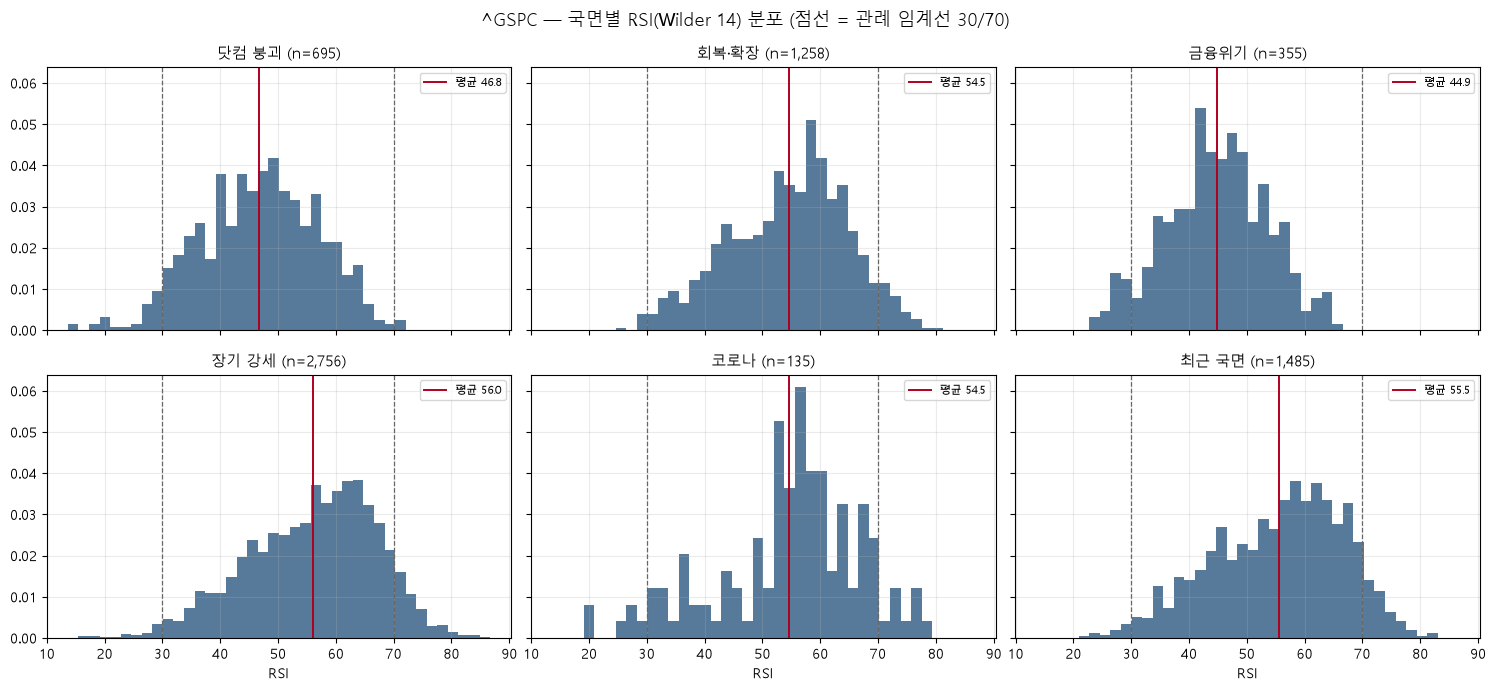

In [35]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "Malgun Gothic"  # 윈도우 한글 폰트
matplotlib.rcParams["axes.unicode_minus"] = False     # 한글 폰트에 유니코드 마이너스 글리프가 없다

phase_keys = list(config.MARKET_REGIMES.keys())  # -> list[str] (6,)


def draw_phase_histograms(column, title, xlabel, figure_path, bins=40, reference_lines=None):
    """국면별 히스토그램 6장을 2x3 그리드로 그린다.

    모든 패널의 x축 범위를 같게 맞춘다. 범위가 제각각이면 분포 모양만 보이고
    "국면 간 위치 차이"가 사라져서, 오늘 확인하려는 것이 그림에서 지워진다.
    """
    values_all = analysis[column].dropna()  # -> Series[float]
    x_min = float(values_all.min())          # -> float
    x_max = float(values_all.max())          # -> float

    figure, axes_grid = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
    axes_flat = axes_grid.flatten()  # -> ndarray[Axes] (6,)

    for position, phase_key in enumerate(phase_keys):
        axes = axes_flat[position]                       # -> Axes
        phase_info = config.MARKET_REGIMES[phase_key]    # -> dict

        phase_mask = analysis["phase"] == phase_key      # -> Series[bool]
        values = analysis.loc[phase_mask, column]        # -> Series[float]
        values = values.dropna()                          # -> Series[float]

        axes.hist(values, bins=bins, range=(x_min, x_max), color="#1f4e79",
                  alpha=0.75, density=True)

        mean_value = float(values.mean())  # -> float
        axes.axvline(mean_value, color="#b00020", linewidth=1.4,
                     label=f"평균 {mean_value:.1f}")

        if reference_lines is not None:
            for reference in reference_lines:
                axes.axvline(reference, color="#666666", linestyle="--", linewidth=0.9)

        axes.set_title(f"{phase_info['name']} (n={len(values):,})", fontsize=11)
        axes.legend(fontsize=8, loc="upper right")
        axes.grid(alpha=0.25)

        if position >= 3:
            axes.set_xlabel(xlabel)

    figure.suptitle(title, fontsize=13)
    figure.tight_layout()
    figure.savefig(figure_path, dpi=config.FIGURE_DPI, bbox_inches=config.FIGURE_BBOX)
    print(f"그림 저장: {figure_path}")

    plt.show()


draw_phase_histograms(
    column="rsi_wilder_14",
    title=f"{signal_ticker} — 국면별 RSI(Wilder {config.RSI_PERIOD}) 분포 (점선 = 관례 임계선 30/70)",
    xlabel="RSI",
    figure_path=config.RSI_PHASE_HIST_FIGURE_PATH,
    reference_lines=[config.RSI_OVERSOLD, config.RSI_OVERBOUGHT],
)

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\day04_atr_phase_hist.png


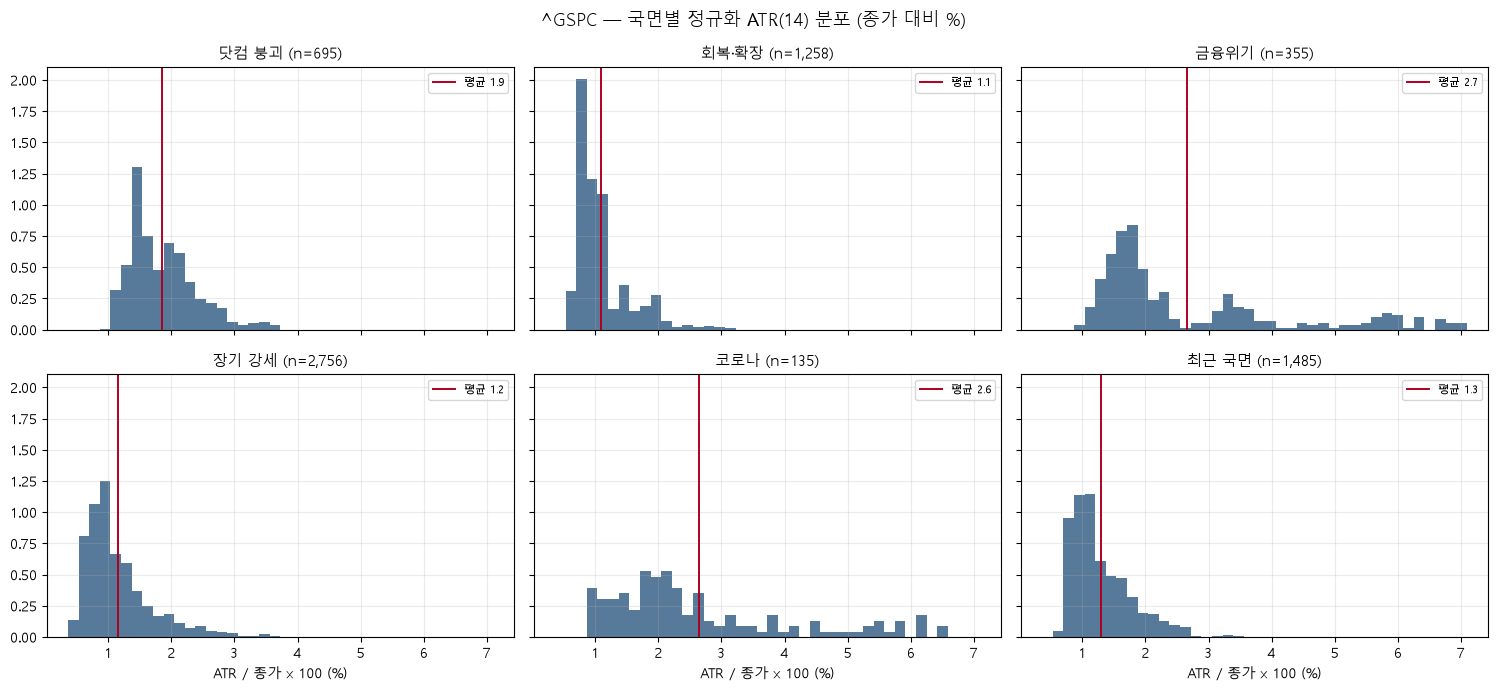

In [36]:
draw_phase_histograms(
    column="atr_pct",
    title=f"{signal_ticker} — 국면별 정규화 ATR({config.ATR_PERIOD}) 분포 (종가 대비 %)",
    xlabel="ATR / 종가 x 100 (%)",
    figure_path=config.ATR_PHASE_HIST_FIGURE_PATH,
)

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\day04_panel_covid.png (패널용 100 DPI)


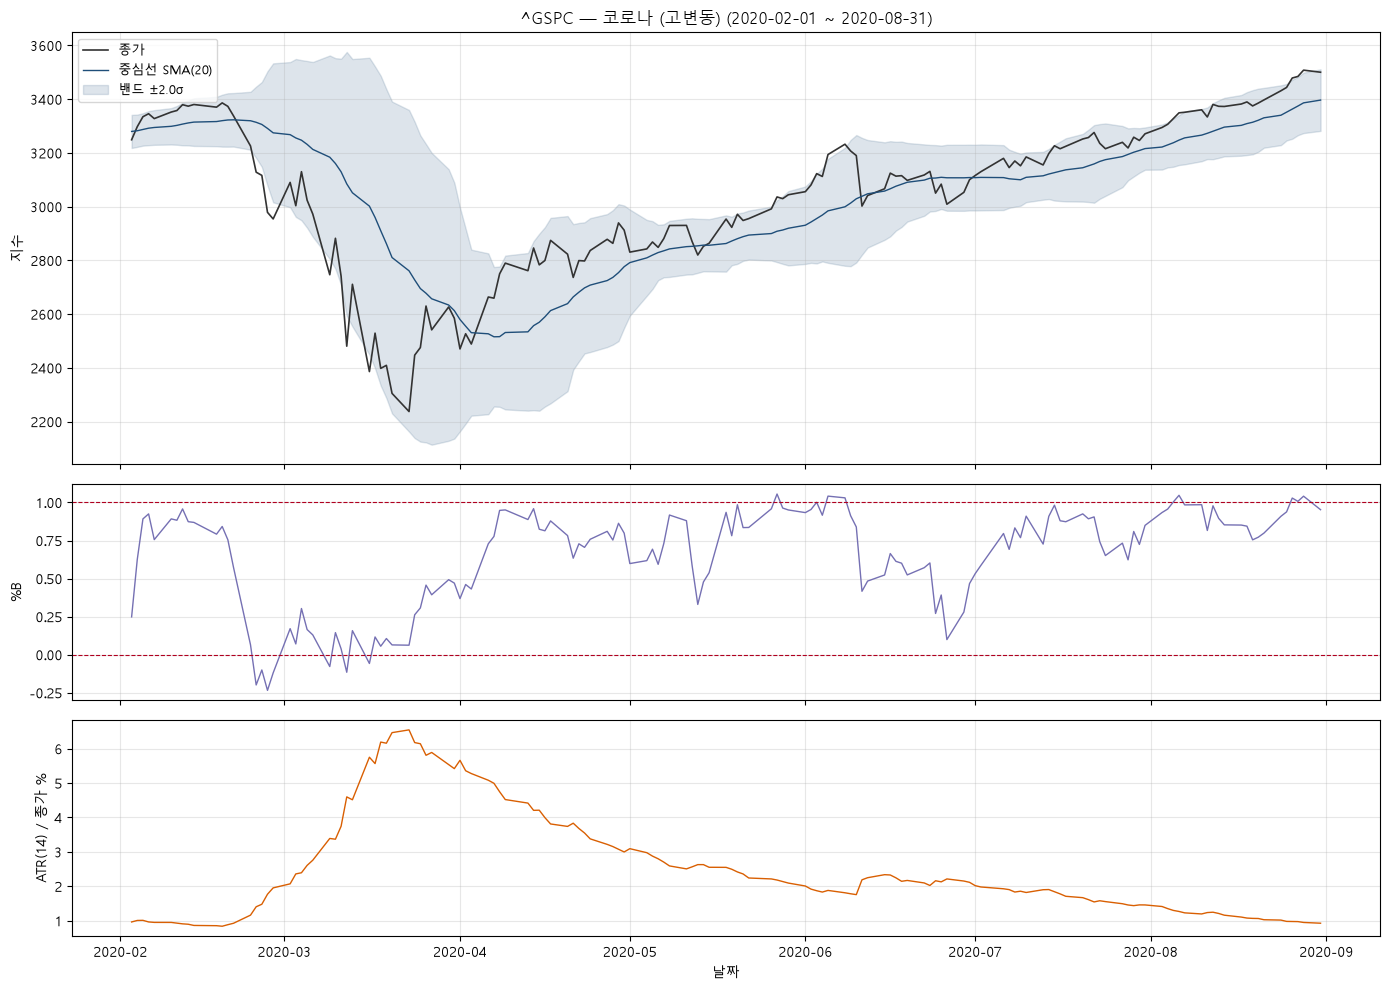

In [37]:
def draw_panel(window_key, figure_path):
    """가격+볼린저 / %B / ATR 3단 패널을 그린다."""
    window_info = config.PANEL_WINDOWS[window_key]        # -> dict
    window_start = pd.Timestamp(window_info["start"])     # -> Timestamp
    window_end = pd.Timestamp(window_info["end"])         # -> Timestamp

    date_column = analysis["date"]                # -> Series[datetime64]
    after_start = date_column >= window_start     # -> Series[bool]
    before_end = date_column <= window_end        # -> Series[bool]
    in_window = after_start & before_end          # -> Series[bool]

    window_df = analysis.loc[in_window]           # -> DataFrame (구간 행 수, 컬럼 수)
    window_df = window_df.reset_index(drop=True)  # -> DataFrame

    figure, axes_list = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                                     gridspec_kw={"height_ratios": [2, 1, 1]})

    plot_x = window_df["date"]  # -> Series[datetime64]

    axes_list[0].plot(plot_x, window_df["close"], linewidth=1.2, color="#333333", label="종가")
    axes_list[0].plot(plot_x, window_df["bb_middle"], linewidth=1.0, color="#1f4e79",
                      label=f"중심선 SMA({config.BB_PERIOD})")
    axes_list[0].fill_between(plot_x, window_df["bb_lower"], window_df["bb_upper"],
                              color="#1f4e79", alpha=0.15,
                              label=f"밴드 ±{config.BB_NUM_STD}σ")
    axes_list[0].set_ylabel("지수")
    axes_list[0].legend(fontsize=9, loc="upper left")
    axes_list[0].grid(alpha=0.3)
    axes_list[0].set_title(
        f"{signal_ticker} — {window_info['name']} ({window_info['start']} ~ {window_info['end']})"
    )

    axes_list[1].plot(plot_x, window_df["bb_percent_b"], linewidth=1.0, color="#7570b3")
    axes_list[1].axhline(1.0, color="#b00020", linestyle="--", linewidth=0.8)
    axes_list[1].axhline(0.0, color="#b00020", linestyle="--", linewidth=0.8)
    axes_list[1].set_ylabel("%B")
    axes_list[1].grid(alpha=0.3)

    axes_list[2].plot(plot_x, window_df["atr_pct"], linewidth=1.0, color="#d95f02")
    axes_list[2].set_ylabel(f"ATR({config.ATR_PERIOD}) / 종가 %")
    axes_list[2].set_xlabel("날짜")
    axes_list[2].grid(alpha=0.3)

    figure.tight_layout()
    figure.savefig(figure_path, dpi=config.FIGURE_DPI_PANEL, bbox_inches=config.FIGURE_BBOX)
    print(f"그림 저장: {figure_path} (패널용 {config.FIGURE_DPI_PANEL} DPI)")

    plt.show()

    return window_df


covid_window = draw_panel("covid", config.COVID_PANEL_FIGURE_PATH)  # -> DataFrame

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\day04_panel_calm.png (패널용 100 DPI)


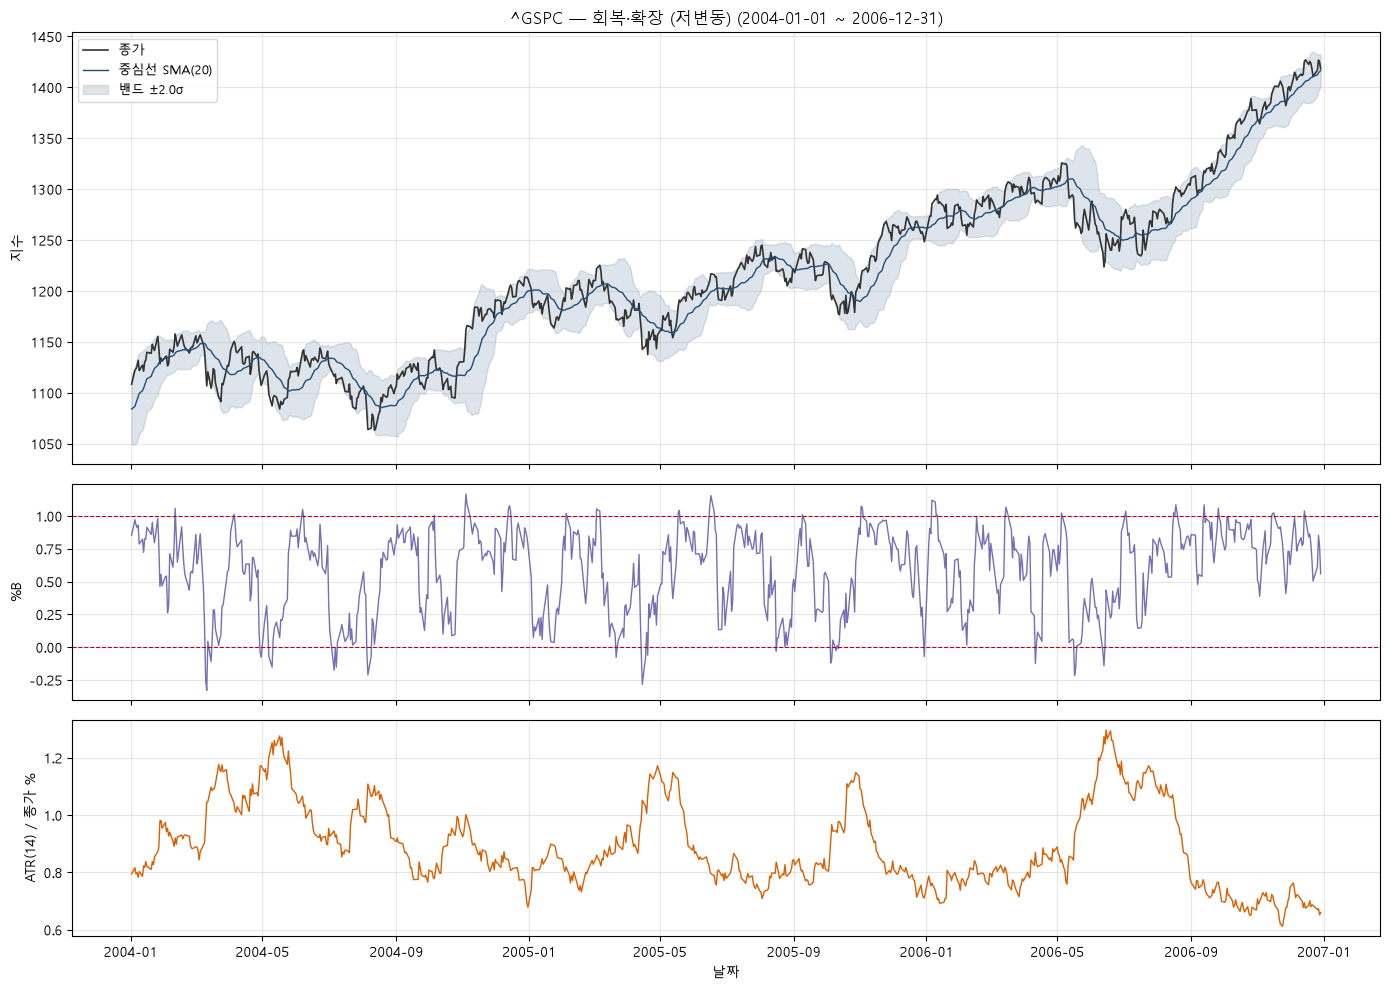

In [38]:
calm_window = draw_panel("calm", config.CALM_PANEL_FIGURE_PATH)  # -> DataFrame

In [39]:
# 두 구간의 수치를 나란히 놓아 그림에서 본 대비를 숫자로 확인한다.
comparison_rows = []  # -> list[dict]

for window_key, window_df in [("covid", covid_window), ("calm", calm_window)]:
    window_info = config.PANEL_WINDOWS[window_key]  # -> dict

    comparison_rows.append(
        {
            "구간": window_info["name"],
            "거래일": len(window_df),
            "정규화ATR 평균%": float(window_df["atr_pct"].mean()),
            "밴드폭 평균%": float(window_df["bb_width"].mean()),
            "RSI 평균": float(window_df["rsi_wilder_14"].mean()),
            "RSI 표준편차": float(window_df["rsi_wilder_14"].std()),
        }
    )

window_comparison = pd.DataFrame(comparison_rows)  # -> DataFrame (2, 6)
window_comparison.round(2)

,구간,거래일,정규화ATR 평균%,밴드폭 평균%,RSI 평균,RSI 표준편차
0,코로나 (고변동),147,2.51,13.50,55.13,12.25
1,회복·확장 (저변동),755,0.89,4.13,54.28,10.48


## 6. 결과표 저장 (리포트 붙여넣기용)

In [40]:
# 대조 결과
markdown_table = indicators.comparison_to_markdown(summary)  # -> str
print(markdown_table)

| 티커 | 비교 | 비교행수 | 최대 절대차 | 평균 절대차 | 최대차 발생일 | 판정 |
|---|---|---|---|---|---|---|
| ^GSPC | ATR vs ta | 9,198 | 1.976e-01 | 3.007e-04 | 1990-01-22 | 구현 차이 — 규명 필요 |
| ^SP500TR | ATR vs ta | 9,198 | 2.025e-01 | 3.082e-04 | 1990-01-22 | 구현 차이 — 규명 필요 |
| ^GSPC | 볼린저 중심선 vs ta | 9,193 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^SP500TR | 볼린저 중심선 vs ta | 9,193 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^GSPC | 볼린저 상단 vs ta | 9,193 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^SP500TR | 볼린저 상단 vs ta | 9,193 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^GSPC | 볼린저 하단 vs ta | 9,193 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^SP500TR | 볼린저 하단 vs ta | 9,193 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^GSPC | 볼린저 %B vs ta | 9,193 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^SP500TR | 볼린저 %B vs ta | 9,193 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^GSPC | 볼린저 밴드폭 vs ta | 9,193 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^SP500TR | 볼린저 밴드폭 vs ta | 9,193 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |

> **읽는 법**
> - 비교는 **양쪽 모두 값이 있는 행에서만**

In [41]:
# 국면별 지표 통계를 하나의 표로 합쳐 저장한다.
combined_rows = []  # -> list[DataFrame]

for label, distribution in [
    ("RSI", rsi_distribution),
    ("ATR_원단위", atr_raw_distribution),
    ("ATR_정규화%", atr_pct_distribution),
    ("볼린저_밴드폭%", bb_width_distribution),
]:
    piece = distribution.copy()   # -> DataFrame (6, 13)
    piece.insert(0, "지표", label)
    combined_rows.append(piece)

phase_indicator_stats = pd.concat(combined_rows, ignore_index=True)  # -> DataFrame (24, 14)

phase_indicator_stats.to_csv(
    config.PHASE_INDICATOR_STATS_CSV_PATH, index=False, encoding="utf-8-sig"
)
print(f"저장 완료: {config.PHASE_INDICATOR_STATS_CSV_PATH} ({len(phase_indicator_stats)}행)")

summary.to_csv(config.VOLATILITY_DIFF_CSV_PATH, index=False, encoding="utf-8-sig")
print(f"저장 완료: {config.VOLATILITY_DIFF_CSV_PATH} ({len(summary)}행)")

저장 완료: C:\Users\chris\projects\sp500-technical-strategy\reports\day04_phase_indicator_stats.csv (24행)
저장 완료: C:\Users\chris\projects\sp500-technical-strategy\reports\day04_volatility_diff.csv (12행)


## 결론

### 1. 자체 검증 6종 전부 통과

외부 라이브러리 없이 TR의 갭 처리(상방 갭에서 `|고가-전일종가|`가 선택되어
TR=22, 고가-저가는 2뿐), 부등식(TR >= 0, TR >= 고가-저가, 18,422행 전부),
표준편차 0 처리, %B 경계값, 상수 시퀀스 ATR=0을 확인했다. 이 뒤에야 ta 대조로
넘어갔다.

### 2. ta 대조 — 볼린저는 `ddof`가 전부, ATR은 워밍업이 전부

**볼린저: `ddof=0`으로 ta와 비트 단위 일치.** 5개 컬럼(중심선·상단·하단·%B·밴드폭)
모두 절대차 정확히 0. `ddof=1`로 두면 최대 절대차가 **15.55 지수 포인트**까지
벌어진다. `pandas.std()`의 기본값이 `ddof=1`이므로, **기본값을 그대로 썼다면
소리 없이 틀린 밴드를 쓰게 된다.**

**ATR: 초기값 씨딩 차이.** 1995년 이전 최대 0.198, 2000년 이후 평균 1.20e-14.
D3의 RSI와 같은 구조지만 **결말이 다르다.**

| | RSI (D3) | ATR (D4) |
|---|---|---|
| 차이의 종착점 | **정확히 0** (비트 단위 일치) | ULP 수준에서 진동 |
| 이유 | 0~100으로 유계 → 흡수되면 영구 고정 | 값이 5 → 86으로 커져 1 ULP도 함께 커짐 |
| 판정 근거 | 절대차 | **상대차** (마지막 3.18e-16 = 머신 엡실론) |

값의 범위가 고정된 지표는 절대차만 봐도 되지만, 가격 단위 지표는 절대차가
커졌을 때 **상대차를 봐야 "오차가 커진 것"과 "값이 커진 것"이 갈린다.**

**ta의 ATR 워밍업은 NaN이 아니라 0.0이다.** `np.zeros`로 배열을 만들고 앞
13행을 채우지 않기 때문이며, `fillna=False`를 줘도 그렇다. "아직 계산할 수
없다"가 "변동성이 0이었다"로 바뀌는 것이라, 이 값이 신호 로직에 들어가면
워밍업 구간 전체가 초저변동 구간으로 오인된다. 우리는 NaN으로 둔다.

### 3. H3 → **H3'** — 국면 간 격차를 결정하는 것은 지표 족이 아니라 구조다

판정 기준: D2에서 확인한 국면 간 연율변동성 배율 **3.30배**를 각 지표가 얼마나
통과시키는가. pass-through는 로그 기준(`ln(지표 배율) / ln(3.30)`)으로 잰다 —
배율의 "차이 없음"은 0이 아니라 1이므로 단순 나눗셈은 눈금이 어긋난다.

| 지표 | 구조 | 국면 간 배율 | log pass-through | 평균 CV |
|---|---|---|---|---|
| **ATR 원값 (포인트)** | 1차 동차 · 무계 | **6.05배** | **150.7%** | 0.363 |
| 볼린저 밴드폭 (%) | 0차 동차 · 무계 | 2.87배 | 88.4% | 0.590 |
| 정규화 ATR (%) | 0차 동차 · 무계 | 2.44배 | 74.6% | 0.445 |
| **볼린저 %B** | **0차 동차 · 유계** | **1.70배** | **44.3%** | 0.612 |
| RSI (Wilder 14) | 0차 동차 · 유계 | 1.25배 | 18.5% | 0.204 |
| *(기준) 연율변동성* | — | *3.30배* | *100%* | — |

#### 결정적 실험 — 이 절의 가치는 숫자가 아니라 설계에 있다

**3층 사다리(RSI / ATR% / 밴드폭)만으로는 결론이 나지 않았다.** 그 결과는 두
해석을 모두 허용했기 때문이다.

- **(A)** 동차 차수와 유계성이 국면 민감도를 결정한다
- **(B)** RSI 계열 vs 변동성 계열이라는 지표 **족(族)** 의 차이일 뿐

세 지표에서는 두 기준이 완전히 겹친다 — RSI는 족으로도 구조로도 "압축하는 쪽",
ATR%·밴드폭은 양쪽 모두 "통과시키는 쪽"이다. 겹치는 관측만 늘려서는 둘을
가를 수 없다.

**%B가 그 겹침을 깨는 유일한 지표다.**

| 기준 | %B가 속하는 쪽 | 예측 |
|---|---|---|
| 지표 족 | 볼린저 (밴드폭과 한 식구) | 2.87 근처 |
| 구조 | 0차 동차 · 유계 (RSI와 같은 층) | 1.25 근처 |

두 가설이 **정반대를 예측하는** 지점을 골라 한 번에 판정하는 설계를
**결정적 실험(critical experiment, experimentum crucis)** 이라 한다. 관측을
많이 모으는 것이 아니라, 가설들이 갈라지는 곳 하나를 정확히 조준하는 것이
핵심이다.

**실측 결과:**

- %B ↔ RSI 거리: **0.450**
- %B ↔ 밴드폭 거리: **1.177**

**%B는 같은 식구인 밴드폭보다 RSI에 2.6배 더 가깝다.** 소속이 아니라 구조를
따라갔다. 가설 (B) 기각, 가설 (A) 지지 → **H3' 확정.**

**ATR 원값이 100%를 넘는 것은 정상이다.** 1차 동차라 가격 수준이 얹히기 때문이다.
분해하면 상한은 `ATR% 배율 2.44 × 가격 수준 배율 4.20 = 10.23`이고 실측 6.05는
그 **59%**다. 상한에 미달하는 이유는 두 배율의 max/min이 서로 다른 국면에서
나오기 때문이다 (ATR% 최대는 금융위기, 가격 최대는 최근 국면, ATR 원값 최대는
코로나).

#### 배율과 CV는 다른 것을 잰다

ATR 원값은 **국면 간 배율이 가장 큰데(6.05) 평균 CV는 가장 작다(0.363).**
모순이 아니라 두 통계가 다른 대상을 재고 있다는 증거다.

- **배율(max/min)** = 국면 **사이**의 차이
- **CV(표준편차/평균)** = 국면 **내부**의 산포

ATR 원값은 국면마다 수준이 크게 다르지만 한 국면 안에서는 가격 수준이 거의
고정돼 있어 상대적으로 잔잔하다. 사다리의 순서는 배율로 판정하고, CV는
"그 국면 안에서 얼마나 요동쳤나"라는 별개 질문의 답으로 읽어야 한다.

**H3'의 진술:**

> 국면 간 분포 차이는 지표의 **동차 차수와 유계성**이 결정한다. 1차 동차(ATR
> 원값, 밴드 절대폭)는 가격 수준과 변동성을 모두 반영해 격차가 가장 크고,
> 0차 동차 무계(ATR%, 밴드폭)는 변동성만, 0차 동차 유계(RSI, %B)는 그마저도
> 압축한다.

**주의 — 유계 지표의 배율은 원점 의존적이다.** RSI(44.9 ↔ 56.0)와 %B(0.38 ↔
0.64)는 스케일이 아니라 **위치**를 재는 값이라, 배율이 눈금의 원점을 어디로
잡느냐에 따라 달라진다. 예컨대 `RSI - 50`으로 재면 부호가 바뀌어 배율 자체가
무의미해진다. 사다리의 순서(ATR 원값 > 밴드폭 > ATR% > %B > RSI)는 견고하지만,
유계 두 행의 **배율 절대값**은 그렇게 읽지 말아야 한다.

### 4. H2 → **H2'** — 안정성을 만드는 것은 임계선의 재조정 여부다

H2는 "변동성 기반 지표(ATR·볼린저)가 국면마다 전혀 다른 빈도로 신호를 낼 것"을
예측했다. 국면별 발동률을 재면 **반대로 나온다.**

| 신호 | 최소 | 최대 | **절대 격차** | 배율 |
|---|---|---|---|---|
| 볼린저 밴드 이탈 | 9.22% (회복·확장) | 12.11% (금융위기) | **2.89%p** | 1.31배 |
| RSI < 30 | 0.79% (회복·확장) | 6.20% (금융위기) | **5.40%p** | 7.80배 |
| RSI > 70 | **0.00%** (금융위기) | 8.45% (장기 강세) | **8.45%p** | 정의 불가 |

주 지표를 배율이 아니라 **절대 격차(%p)** 로 둔다. RSI > 70은 금융위기에서
발동률이 정확히 0이라 배율의 분모가 0이 되는데, 이는 무한대가 아니라
**정의되지 않음**이므로 비율 통계를 쓸 수 없다.

**신호 빈도가 국면에 안정적인 쪽은 볼린저이고, 요동치는 쪽은 RSI다.**
H3'(지표 값의 격차)와 정반대의 순서다. 두 질문이 다른 질문이었기 때문이다.

- **볼린저의 임계선은 로컬 조건에 재조정된다.** `±2σ`의 `σ`가 같은 20일
  변동성에서 나오므로, 변동성이 커지면 임계선도 함께 벌어진다. 지표 값이
  2.87배 벌어져도 발동률은 1.31배에 그친다.
- **RSI의 임계선은 재조정되지 않는다.** 30/70은 무엇에도 곱해지지 않는 절대
  수치다. 지표 값은 1.25배밖에 안 움직이는데도 분포 전체가 이동하면서 한쪽
  꼬리만 임계선을 넘어, 발동률이 7.80배 벌어진다.

**H2'의 진술:**

> 신호 빈도의 국면 안정성은 지표의 변동성 민감도가 아니라 **임계선이 로컬
> 조건에 재조정되는지 여부**가 결정한다. 조건부 임계선(볼린저 ±2σ)은 지표 값이
> 2.87배 벌어져도 발동률을 1.31배로 유지하지만, 무조건부 임계선(RSI 30/70)은
> 지표 값이 1.25배밖에 안 움직여도 발동률이 7.80배 벌어진다.

"고정 임계선"이라는 표현은 쓰지 않는다 — **볼린저의 2σ도 고정된 숫자다.**
차이는 그 숫자가 무엇에 곱해지는가에 있다.

**판정을 유보하는 부분:** 발동률이 안정적이라는 것이 "볼린저 신호가 더 낫다"는
뜻은 아니다. 발동률이 균일해도 각 신호의 사후 수익이 0이면 쓸모없다. 어느 쪽이
유효한지는 8/6 이벤트 스터디와 8/14 손익분기 분석에서만 판정할 수 있다.

### 4-2. 관찰 — 금융위기 구간 RSI > 70의 이항적 소멸

금융위기 355거래일 중 RSI > 70인 날이 **0일**이다. "발동률이 낮다"가 아니라
**신호의 이항적 소멸**이다. RSI > 70을 청산 조건으로 쓰는 전략은 이 구간에서
청산 신호가 존재하지 않아 약 **18개월 강제 보유**가 되며, 그 구간의 `^GSPC`
수익률은 **-56.8%** 다. → `reports/why_it_fails.md` 후보 (8/14)

### 4-3. 상관계수 — 두 개는 sanity check, 하나는 해석 대상

| 비교 | 상관 | 성격 |
|---|---|---|
| 정규화 ATR ↔ rolling 변동성 | **+0.963** | 구현 sanity check |
| 볼린저 밴드폭 ↔ rolling 변동성 | **+0.844** | 구현 sanity check |
| RSI ↔ rolling 변동성 | **−0.347** | **해석 대상** |

앞의 두 개가 높은 것은 발견이 아니다. **겹치는 창에서 같은 것(최근 변동성)을
재고 있으므로 높게 나오는 것이 당연하고, 낮았다면 오히려 구현을 의심해야 한다.**
밴드폭이 ATR%보다 낮은 것은 창 길이(20 vs 14 vs 20), 평활(SMA vs Wilder),
입력(종가만 vs 고저+갭)이 모두 다르기 때문이며, 그럼에도 +0.84면 정합적이다.

**요점은 RSI가 0이 아니라 음수라는 것이다.** RSI가 변동성에 순수하게 불변이라면
상관은 0 근처여야 하는데 −0.35는 0이 아니다. 원인은 스케일이 아니라 **방향**이다
— 하락 뒤에 변동성이 더 크게 오르는 **레버리지 효과(leverage effect, 변동성
비대칭)** 가 알려져 있고, RSI는 방향을 재는 지표이므로 그 결합만큼 음의 상관이
남는다.

> RSI는 변동성의 **크기(scale)** 를 약분해 지우지만, 변동성과 **방향의 결합**까지는
> 지우지 못한다. 잔여 상관 −0.347이 그 몫이다.

### 4-4. 볼린저 이탈률과 D2 팻테일의 연결

밴드 이탈률 9.22~12.11%는 **밴드 안에 87.9~90.8%가 들어온다**는 뜻이다.
정규분포 `±2σ`의 이론값 **95.45%** 보다 6국면 전부에서 낮다.

D2에서 확인한 초과첨도 > 0 (6국면 전부, 1.24~5.82)을 다른 경로에서 본 것이다 —
꼬리가 두꺼우면 `±2σ` 밖 사건이 잦아진다. 따라서 "밴드를 벗어나면 이례적"이라는
해석은 정규분포를 전제하며, 실제로는 **10일에 하루꼴**이라 이례적이라고 부르기
어렵다.

### 5. H4 판정 — 70/30은 대칭이 아니다

분석 구간 6,684일 `^GSPC` RSI(Wilder 14) 분포:

- **중앙값 55.15** — 대칭이라면 50이어야 하는데 **+5.15 위로 치우쳐 있다**
- 분위수: 5% = 34.35 / 25% = 45.86 / 50% = 55.15 / 75% = 62.54 / 95% = 70.87

관례 임계선이 실제로 얼마나 희소한 사건인지 역산하면:

| 임계선 | 실제 발생률 | 해석 |
|---|---|---|
| RSI < 30 | **1.89%** | 하위 약 2분위 — 매우 드문 사건 |
| RSI > 70 | **6.37%** | 상위 약 6% — 5%보다 흔함 |
| **비대칭 배율** | **3.38배** | 같은 "극단"이 아니다 |

**70은 사실상 95분위(70.87)와 거의 일치하지만, 30은 5분위(34.35)보다 한참
아래다.** 즉 관례값 30/70은 "위아래 대칭인 극단"이 아니라, **위쪽은 5% 규칙,
아래쪽은 2% 규칙**을 쓰고 있는 셈이다.

이것이 D3에서 관찰한 과매수 발동률 17.7%(단순SMA)·6.4%(Wilder)가 과매도보다
훨씬 높았던 이유다. 26년간 우상향한 자산이라 RSI 분포 자체가 위로 밀려 있다.

**임계선을 바꾸자는 것이 아니다.** 관례값 30/70을 쓰는 것은 곧 **"이 자산의
RSI 분포가 50 대칭이다"라고 가정하는 것**이고, 그 가정이 이 표본에서 성립하지
않는다는 사실을 기록해두는 것이 목적이다. 8/6 `docs/signal_spec.md`에서
임계선의 근거를 적을 때 이 수치를 인용한다.

### 5-2. 사전 예측 대조 — 무엇이 실질적 예측이었나

실행 전에 기록한 예측과 실측을 대조한다.

| 항목 | 예측 | 실측 | 판정 |
|---|---|---|---|
| %B 국면 간 배율 | 1.45 (구간 1.2~1.8) | **1.697** | 구간 내 |
| ATR 원값 배율 | 6배 (구간 4.5~8) | **6.049** | 구간 내 |
| 순서 | ATR원값 > 밴드폭 > ATR% > %B > RSI | **동일** | 적중 |
| ATR 원값 최대 국면 | 코로나 | **코로나** | 적중 |
| ATR 원값 최소 국면 | 회복·확장 | **회복·확장** | 적중 |

**"전부 맞혔다"로 뭉뚱그리면 과장이 된다.** 항목별 실질 난이도가 다르다.

**통찰이 아닌 항목 (산술).** ATR 원값 6.049와 최대/최소 국면 적중은 예측이라기
보다 **계산**이다. `ATR_raw = ATR% × C`는 항등식이므로, ATR%와 가격 수준의
국면별 값을 알면 답은 산술로 나온다. "잘 맞혔다"가 아니라 **"계산이 맞았다"** 에
해당한다. 순서 예측도 대부분 이 항등식과 동차 차수 정의에서 따라 나온다.

**실질적 예측은 %B 하나였다.** 그리고 절반만 맞았다.

- **방향은 논증했다** — %B는 평활이 없어 당일 위치를 그대로 반영하므로
  14일 Wilder 평활을 거치는 RSI보다 국면 배율이 클 것이라 예상했고, 맞았다.
- **중심값 1.45의 근거는 약했다.** 실측 1.697은 예상 방향으로 **더 갔다.**
  → **평활의 압축 효과를 과소평가했다.**

**교정값 기록:**

$$
\frac{\text{RSI (14일 Wilder 평활)}}{\text{%B (평활 없음)}}
= \frac{1.247}{1.697} = 0.735
$$

> **평활이 유계 지표의 국면 간 배율을 약 26% 깎는다.**
> 유계 지표끼리 비교할 때 다음 예측에 이 값을 반영한다.

#### 반증선 판정의 정당성 — 사후에 기준을 옮긴 것이 아니다

ATR 원값의 반증선은 "분해 상한 초과 시 계산 오류"였는데, 상한 추정치가
**9.3(예상) → 10.23(실측)** 으로 움직였다. 사후에 기준을 바꾼 것처럼 보일 수
있으므로 구분을 명시해둔다.

- **상한은 원 데이터에서 결정론적으로 계산되는 값**이다 (`ATR% 배율 × 가격
  수준 배율`). 결과를 보고 조정한 것이 아니라, 애초에 데이터가 정하는 값을
  내가 3.8이라는 **부정확한 입력 추정치**로 어림했을 뿐이다.
- **판정 기준의 정의 자체는 사전에 고정돼 있었다.** 정의가 같고 입력만 정확해진
  것이므로 판정은 유효하다. 실측 6.049는 상한의 **59%** 지점으로 통과.

**이 구분은 8/6 순열검정에서 유의수준을 정할 때 그대로 적용된다.** 데이터가
결정하는 값을 정확히 계산해 넣는 것은 정당하지만, **결과를 본 뒤 임계를 옮기는
것은 위와 달리 정당화되지 않는다.**

### 6. 데이터에 대해 확인한 것 (서술 수위 주의)

**`^SP500TR`의 고가·저가.** yfinance 피드 기준 `^SP500TR`은 **52.9%의 거래일에서
`High == Low`** 다. H·L에 장중 정보가 없으므로 **TR·ATR을 계산할 수 없다.**
지수 산출 방식 자체의 문제인지 데이터 제공자의 결측 처리인지는 **미확인**이다.
어느 쪽이든 결론은 같다 — H·L을 쓰는 지표는 이 티커에서 쓸 수 없고, 이는
CLAUDE.md 규칙 5(신호 생성은 `^GSPC`)와 일치한다.

**`^GSPC`의 갭 빈도.** 1990년 이후 `tr_hl` 78.0% / `tr_hc` 12.2% / `tr_lc` 9.8%로,
**22.0%의 날에 갭 항이 장중 범위보다 컸다.** 고가-저가만 썼다면 다섯 날 중
하루꼴로 실제 변동을 과소평가했을 것이므로, TR을 쓰는 근거로는 충분하다.

다만 **"S&P 500이 22% 확률로 갭을 낸다"로 읽으면 과잉 해석이다.** 지수의 시가는
구성종목 시가로 계산되는데 종목별 개장 체결 시각이 다르므로, 지수 레벨의 갭은
개별 종목의 갭보다 인위적 성격이 있다. 여기서 확인한 것은 "지수 시계열에서
갭 항이 선택되는 빈도"이지 "시장이 갭을 내는 빈도"가 아니다.

### 7. (a)/(b)/(c) 분류 틀이 실제 판별력을 갖는다

D3와 D4에서 **같은 라이브러리, 같은 평활 함수(`wilder_rma`)** 를 썼는데
차이의 분류가 갈렸다.

| | D3 RSI 시드 차이 | D4 ATR 잔차 |
|---|---|---|
| 분류 | **(b) 가정 차이** | **(c) 반올림 오차** |
| 근거 | 초기값 씨딩 관례가 다름. 1992-03-27에 비트 단위로 흡수 | 씨딩 차이가 감쇠한 뒤 남은 ULP 진동. 마지막 상대차 3.18e-16 |
| 왜 결말이 다른가 | RSI는 0~100 유계 → 흡수되면 영구 고정 | ATR은 값이 5→86으로 커져 1 ULP도 함께 커짐 |

분류 틀이 모든 차이를 "구현 차이"로 뭉뚱그렸다면 이 구분이 나오지 않았을 것이다.
**같은 원인(씨딩)에서 출발해도 지표의 유계성에 따라 종착점이 달라진다**는 사실은
틀이 실제로 작동한다는 증거이며, 2단계 프레임워크 대조 리포트 서두의 재료다.

### 다음에 확인할 것

- 8/6 `docs/signal_spec.md`: 평활 방식(D3) + `ddof`(D4) + 임계선 근거(H4)를
  모두 적어야 신호가 특정된다
- 8/6 이벤트 스터디: 발동률이 균일한 볼린저 신호와 요동치는 RSI 신호 중
  **사후 수익이 있는 쪽**이 어디인가
- H2' 재검증: 무조건부 임계선을 조건부로 바꾸면 RSI 발동률의 국면 간 격차가
  줄어드는가

### 하지 않을 것 — 전 표본 분위수를 임계선으로 쓰는 것

H4에서 나온 분위수(5% = 34.35, 95% = 70.87)를 임계선으로 **대체하지 않는다.**

이 값은 2000~2026년 **전체**로 계산한 것이라, 2003년의 매매 결정에 쓰면 그
시점에 알 수 없었던 정보를 쓰는 것이 된다. 명백한 미래 참조이고, ML 용어로는
테스트셋 통계로 전처리 파라미터를 정하는 **데이터 누수(data leakage)** 다.
백테스트 성과를 **확실히 부풀리는 방향으로** 작동한다는 점이 특히 위험하다.

적응형 임계선을 쓰려면 **확장 창(expanding window) + `shift(1)`** 이 필수이며,
이는 8/6 `docs/signal_spec.md`에서 설계한다. **오늘은 코드에 넣지 않는다.**

---

**내 해석 (직접 채울 것):**
